In [1]:
# The purpose of this notebook is that you need to join together all the files, 
# and then normalise them, and get them into a format that matches the format that Clara had for them 

In [2]:
import numpy as np
import xarray as xr    
import glob
import pandas as pd
import itertools
import sklearn

import matplotlib.pyplot as plt

In [3]:
# Set all the filepaths that will be required 
filepath_data_ho = "/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/"
filepath_masks = filepath_data_ho + "masks_"
#filepath_nico_on_nemo = filepath_data_ho + "nico_on_nemo_" + nemo_run + '.nc'
#filepath_mask_nemo_run = filepath_masks + nemo_run + '.nc'
filepath_nn_input = filepath_data_ho + "nn_input_"
#filepath_slopes = filepath_nn_input + nemo_run + '_' + 'redo_slopes2' + '.nc'
filepath_areas = "/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/areas.nc"

# Set where you would like to save the data 
data_out_fp = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
# Create a dataframe with all the data which is saved in this location
#intermediate_filepath = data_out_fp + nemo_run + '_' + 'whole_dataset' + '_' + 'not_yet_normalised.csv'
# Creat a dataframe with only the specified data (which is also saved in this location) 
#this_collection = 'no_mar_oct'
#fp_metrics = data_out_fp + this_collection + '_' + 'metrics_norm.nc'
#fp_var_train_norm = data_out_fp + this_collection + '_' + 'train_data.nc'
#fp_var_val_norm = data_out_fp + this_collection + '_' + 'val_data.nc'

### **You can start here if you've already merged together the simulations into a pandas dataframe (saved as intermediate_filepath)**

**Separate out the testing data, and then split the rest into training and validation datasets**

In [4]:
this_collection = 'OPM026_OPM0263_OPM031_Christoph'

In [5]:
collections = this_collection.split('_')
print(collections)

['OPM026', 'OPM0263', 'OPM031', 'Christoph']


In [6]:
filepaths = []
for i in range(len(collections)):
    if collections[i] == 'Christoph':
        collections[i] = 'Christoph_v2'
    filepaths.append(data_out_fp + collections[i] + '_' + 'whole_dataset' + '_' + 'not_yet_normalised.csv')
filepaths

['/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_whole_dataset_not_yet_normalised.csv',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM031_whole_dataset_not_yet_normalised.csv',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/Christoph_v2_whole_dataset_not_yet_normalised.csv']

In [ ]:
df_0_sin = pd.read_csv(filepaths[0], nrows = 11325)
print('Loaded 0')
df_1_sin = pd.read_csv(filepaths[1], nrows = 16336)
print('Loaded 1')
df_2_sin = pd.read_csv(filepaths[2], nrows = 11325)
print('Loaded 2')
df_3_sin = pd.read_csv(filepaths[3], nrows = 11338)
print('Loaded 3')

In [7]:
df_0 = pd.read_csv(filepaths[0])
print('Loaded 0')
df_1 = pd.read_csv(filepaths[1])
print('Loaded 1')
df_2 = pd.read_csv(filepaths[2])
print('Loaded 2')
df_3 = pd.read_csv(filepaths[3])
print('Loaded 3')

Loaded 0
Loaded 1
Loaded 2
Loaded 3


## **To plot distribution plots for all the variables**

In [8]:

var_list =   ['distances_GL', 'distances_OO', 'distances_OC',
                 'temperature_prop', 'mean_T', 'std_T',
                 'salinity_prop', 'mean_S', 'std_S',
                 'corrected_isdraft', 'slope_is_across_front', 'slope_is_towards_front',
                 'bathymetry', 'slope_ba_across_front', 'slope_ba_towards_front',
                 'melt_m_ice_per_y', 'melt_m_ice_per_y']

In [9]:
var_list =   ['temperature_prop', 'salinity_prop', 
                 'corrected_isdraft', 
                 'bathymetry', 
                 'melt_m_ice_per_y']
#var_list =   ['temperature_prop', 'salinity_prop', 
#                 'corrected_isdraft', 
#                 'bathymetry', 
#                 'melt_Gt']

In [10]:
variable = var_list[0]
bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
bins = np.linspace(bounds[0], bounds[1], 50)
freq0, _ = np.histogram(df_0[variable], bins = bins);
freq1, _ = np.histogram(df_1[variable], bins = bins);
freq2, _ = np.histogram(df_2[variable], bins = bins);
freq3, _ = np.histogram(df_3[variable], bins = bins);
freq0_arr = np.array(freq0, dtype = 'float')
freq0_arr[freq0_arr == 0] = np.nan
freq1_arr = np.array(freq1, dtype = 'float')
freq1_arr[freq1_arr == 0] = np.nan
freq2_arr = np.array(freq2, dtype = 'float')
freq2_arr[freq2_arr == 0] = np.nan
freq3_arr = np.array(freq3, dtype = 'float')
freq3_arr[freq3_arr == 0] = np.nan
freq0 = freq0_arr
freq1 = freq1_arr
freq2 = freq2_arr
freq3 = freq3_arr

In [11]:
for i in range(len(var_list)):
    print(int(np.mod(i,3)), int((i - int(np.mod(i,3)))/3))

0 0
1 0
2 0
0 1
1 1


In [12]:
df_0.loc[:,'melt_Gt'] = df_0.melt_m_ice_per_y*df_0.area * 31536000 * 1/1e12
df_1.loc[:,'melt_Gt'] = df_1.melt_m_ice_per_y*df_1.area * 31536000 * 1/1e12
df_2.loc[:,'melt_Gt'] = df_2.melt_m_ice_per_y*df_2.area * 31536000 * 1/1e12
df_3.loc[:,'melt_Gt'] = df_3.melt_m_ice_per_y*df_3.area * 31536000 * 1/1e12

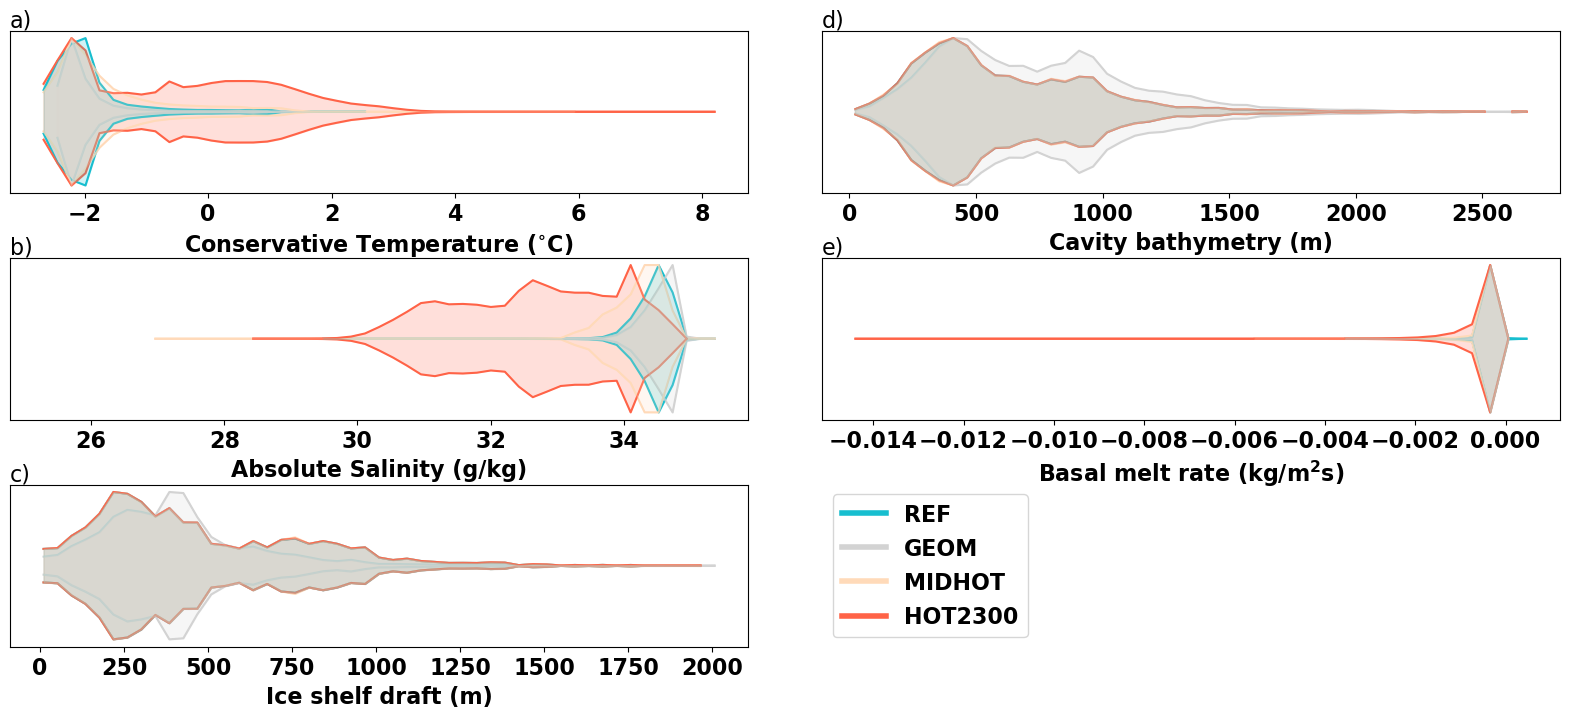

In [14]:
labels = ('Conservative Temperature ($^{{\\circ}}$C)', 'Absolute Salinity (g/kg)', \
          'Ice shelf draft (m)', 'Cavity bathymetry (m)', 'Basal melt rate (kg/m$^2$s)')
plt_labels = ('a)', 'b)', 'c)', 'd)', 'e)')
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(3,2,figsize = (20,8))
    fig.subplots_adjust(wspace=0.1, hspace = 0.4)
    for i in range(len(var_list)):
        ax = axs[int(np.mod(i,3)), int((i - int(np.mod(i,3)))/3)]
        variable = var_list[i]
        #if variable == 'melt_m_ice_per_y':
        #    bounds = (-0.00001,0.00001)
        #else:
        bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
        np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
        bins = np.linspace(bounds[0], bounds[1], 50)
        freq0, _ = np.histogram(df_0[variable], bins = bins);
        freq1, _ = np.histogram(df_1[variable], bins = bins);
        freq2, _ = np.histogram(df_2[variable], bins = bins);
        if variable in ('melt_m_ice_per_y', 'melt_Gt'):
            freq3, _ = np.histogram(-df_3[variable], bins = bins);
        else:
            freq3, _ = np.histogram(df_3[variable], bins = bins);
        freq0_arr = np.array(freq0, dtype = 'float')
        freq0_arr[freq0_arr == 0] = np.nan
        freq1_arr = np.array(freq1, dtype = 'float')
        freq1_arr[freq1_arr == 0] = np.nan
        freq2_arr = np.array(freq2, dtype = 'float')
        freq2_arr[freq2_arr == 0] = np.nan
        freq3_arr = np.array(freq3, dtype = 'float')
        freq3_arr[freq3_arr == 0] = np.nan
        freq0 = freq0_arr
        freq1 = freq1_arr
        freq2 = freq2_arr
        freq3 = freq3_arr
    
        #freq0 = freq0s[i]
        ax.plot(bins[:-1], freq0/np.nanmax(freq0), color = 'C9')
        ax.plot(bins[:-1], -freq0/np.nanmax(freq0), color = 'C9')
        ax.fill_between(bins[:-1], -freq0/np.nanmax(freq0), freq0/np.nanmax(freq0), color = 'C9', alpha = 0.2, zorder = 10, \
                          label = 'OPM026')
        ax.plot(bins[:-1], freq1/np.nanmax(freq1), color = 'lightgrey')
        ax.plot(bins[:-1], -freq1/np.nanmax(freq1), color = 'lightgrey')
        ax.fill_between(bins[:-1], -freq1/np.nanmax(freq1), freq1/np.nanmax(freq1), color = 'lightgrey', alpha = 0.2, zorder = 10, \
                          label = 'OPM0263')
        # freq3 = freq3s[i]
        ax.plot(bins[:-1], freq3/np.nanmax(freq3), color = 'peachpuff')
        ax.plot(bins[:-1], -freq3/np.nanmax(freq3), color = 'peachpuff')
        ax.fill_between(bins[:-1], -freq3/np.nanmax(freq3), freq3/np.nanmax(freq3), color = 'peachpuff', alpha = 0.2, zorder = 10, \
                          label = 'Christoph')
        #freq2 = freq2s[i]
        ax.plot(bins[:-1], freq2/np.nanmax(freq2), color = 'tomato')
        ax.plot(bins[:-1], -freq2/np.nanmax(freq2), color = 'tomato')
        ax.fill_between(bins[:-1], -freq2/np.nanmax(freq2), freq2/np.nanmax(freq2), color = 'tomato', alpha = 0.2, zorder = 0, \
                          label = 'OPM031')
        ax.set_yticklabels([])     # Remove tick labels
        ax.set_yticks([]) 
        ax.set_xlabel(labels[i])

        ax.annotate(plt_labels[i], xytext = (0,1.02), \
                xy = (0.5,0.5), xycoords = 'axes fraction', fontweight = 'normal')
    
    ax = axs[2,1]
    x = (0,2)
    y = (1,1)
    ax.plot(x,y, color = 'C9', label = 'REF')
    ax.plot(x,y, color = 'lightgrey', label = 'GEOM')
    ax.plot(x,y, color = 'peachpuff', label = 'MIDHOT')
    ax.plot(x,y, color = 'tomato', label = 'HOT2300')
    leg = ax.legend(loc = 'center left')
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ax.set_xlim(3,4)
    ax.axis('off')
    plt.show()
    
    
    fig.savefig('FIGURES/data_distributions.pdf', dpi = 200, bbox_inches = 'tight')

In [15]:
df0_lat_lon = df_0.groupby(['lat','lon','year'], as_index = False).min()
df2_lat_lon = df_2.groupby(['lat','lon','year'], as_index = False).min()
df3_lat_lon = df_3.groupby(['lat','lon','year'], as_index = False).max()

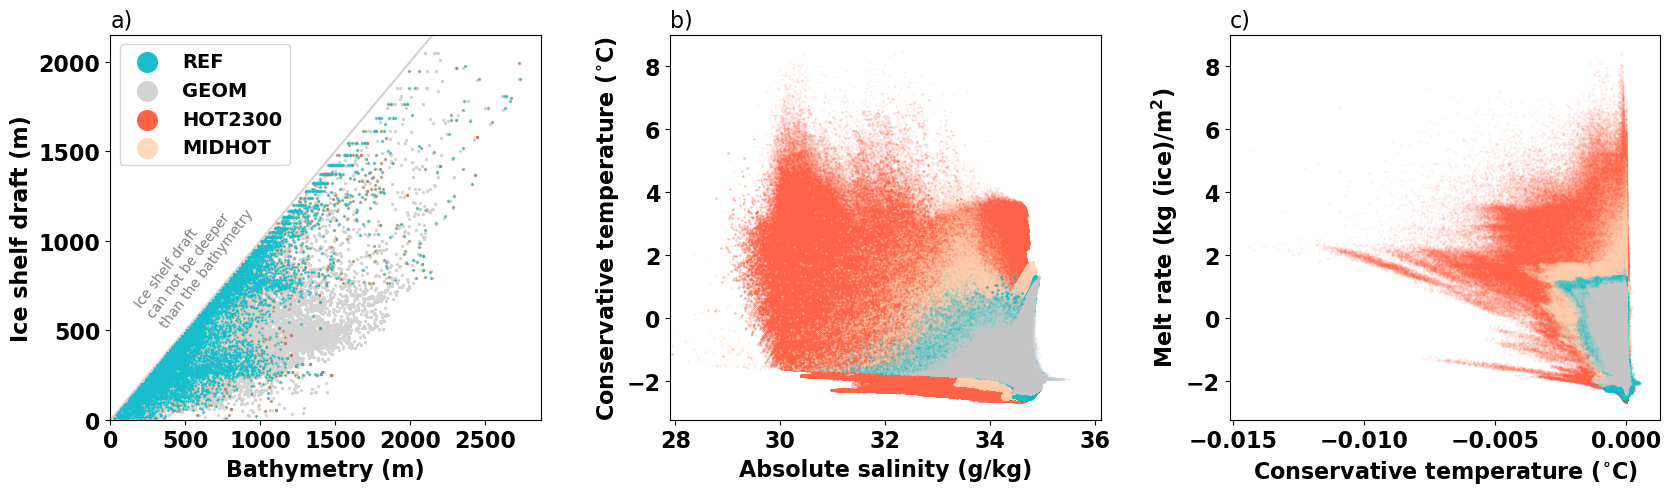

In [16]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,3, figsize = (20,5))
    fig.subplots_adjust(wspace=0.3, hspace = 0.7)
    
    ax = axs[0]
    ax.scatter(df_0_sin.bathymetry, df_0_sin.corrected_isdraft, s = 0.5, alpha = 1, zorder = 10, color = 'C9')
    ax.scatter(df_0_sin.bathymetry[0:1], df_0_sin.corrected_isdraft[0:1], s = 2, alpha = 1, zorder = 10, color = 'C9', label = 'REF')
    ax.scatter(df_1_sin.bathymetry, df_1_sin.corrected_isdraft, s = 2, alpha = 1, color = 'lightgrey', label = 'GEOM')
    ax.scatter(df_2_sin.bathymetry, df_2_sin.corrected_isdraft, s = 2, alpha = 1, color = 'tomato', label = 'HOT2300')
    ax.scatter(df_3_sin.bathymetry, df_3_sin.corrected_isdraft, s = 2, alpha = 1, color = 'peachpuff', label = 'MIDHOT')
    ylims = ax.get_ylim()
    ax.plot(ax.get_ylim(),ax.get_ylim(), color = 'lightgrey')
    ax.set_ylim(0,ylims[1])
    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_xlabel('Bathymetry (m)')
    ax.set_ylabel('Ice shelf draft (m)')
    ax.annotate('Ice shelf draft\ncan not be deeper\nthan the bathymetry', \
                xytext = (0.05,0.42), xy = (0.02,0.46), xycoords = 'axes fraction', rotation = 53, 
               va = 'center', fontsize = 10, color = 'grey', fontweight = 'normal')
    leg = ax.legend(loc = 2, markerscale = 10, fontsize = 14)
    
    ax = axs[1]
    ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 10, color = 'C9')
    ax.scatter(df_1.salinity_prop, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 12, color = 'lightgrey')
    ax.scatter(df_2.salinity_prop, df_2.temperature_prop, s = 0.1, alpha = 0.2, color = 'tomato')
    ax.scatter(df_3.salinity_prop, df_3.temperature_prop, s = 0.1, alpha = 0.2, color = 'peachpuff')
    ax.set_xlabel('Absolute salinity (g/kg)')
    ax.set_ylabel('Conservative temperature ($^{{\\circ}}$C)')
    ax.set_xlim(27.9,36.1)

    ax = axs[2]
    ax.scatter(df_0.melt_m_ice_per_y, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 10, color = 'C9')
    ax.scatter(df_1.melt_m_ice_per_y, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 12, color = 'lightgrey')
    ax.scatter(df_2.melt_m_ice_per_y, df_2.temperature_prop, s = 0.1, alpha = 0.2, color = 'tomato')
    ax.scatter(-df_3.melt_m_ice_per_y, df_3.temperature_prop, s = 0.1, alpha = 0.2, color = 'peachpuff')
    ax.set_ylabel('Melt rate (kg (ice)/m$^2$)')
    ax.set_xlabel('Conservative temperature ($^{{\\circ}}$C)')

    plt_labels = ('a)', 'b)', 'c)')
    for i in range(3):
        axs[i].annotate(plt_labels[i], xytext = (0,1.02), \
                xy = (0.5,0.5), xycoords = 'axes fraction', fontweight = 'normal')

    plt.show()

In [ ]:
df_0.groupby(['lat','lon', 'year','month']).min()

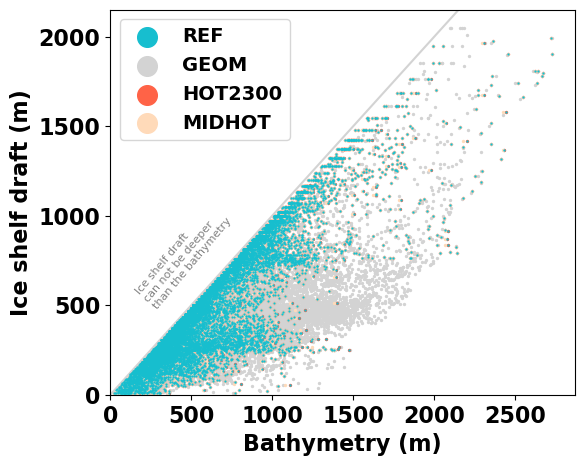

In [17]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_0_sin.bathymetry, df_0_sin.corrected_isdraft, s = 0.5, alpha = 1, zorder = 10, color = 'C9')
    ax.scatter(df_0_sin.bathymetry[0:1], df_0_sin.corrected_isdraft[0:1], s = 2, alpha = 1, zorder = 10, color = 'C9', label = 'REF')
    ax.scatter(df_1_sin.bathymetry, df_1_sin.corrected_isdraft, s = 2, alpha = 1, color = 'lightgrey', label = 'GEOM')
    ax.scatter(df_2_sin.bathymetry, df_2_sin.corrected_isdraft, s = 2, alpha = 1, color = 'tomato', label = 'HOT2300')
    ax.scatter(df_3_sin.bathymetry, df_3_sin.corrected_isdraft, s = 2, alpha = 1, color = 'peachpuff', label = 'MIDHOT')
    ylims = ax.get_ylim()
    ax.plot(ax.get_ylim(),ax.get_ylim(), color = 'lightgrey')
    ax.set_ylim(0,ylims[1])
    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_xlabel('Bathymetry (m)')
    ax.set_ylabel('Ice shelf draft (m)')
    ax.annotate('Ice shelf draft\ncan not be deeper\nthan the bathymetry', \
                xytext = (0.05,0.36), xy = (0.02,0.36), xycoords = 'axes fraction', rotation = 50, 
               va = 'center', fontsize = 8, color = 'grey', fontweight = 'normal')
    leg = ax.legend(loc = 2, markerscale = 10, fontsize = 14)
    plt.show()

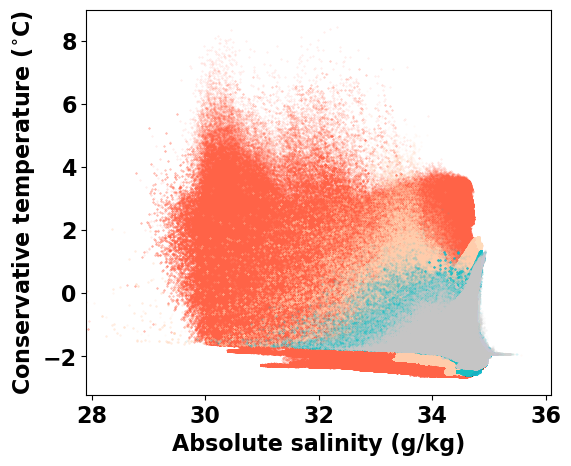

In [18]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 10, color = 'C9')
    ax.scatter(df_1.salinity_prop, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 12, color = 'lightgrey')
    ax.scatter(df_2.salinity_prop, df_2.temperature_prop, s = 0.1, alpha = 0.2, color = 'tomato')
    ax.scatter(df_3.salinity_prop, df_3.temperature_prop, s = 0.1, alpha = 0.2, color = 'peachpuff')
    ax.set_xlabel('Absolute salinity (g/kg)')
    ax.set_ylabel('Conservative temperature ($^{{\\circ}}$C)')
    ax.set_xlim(27.9,36.1)
    plt.show()

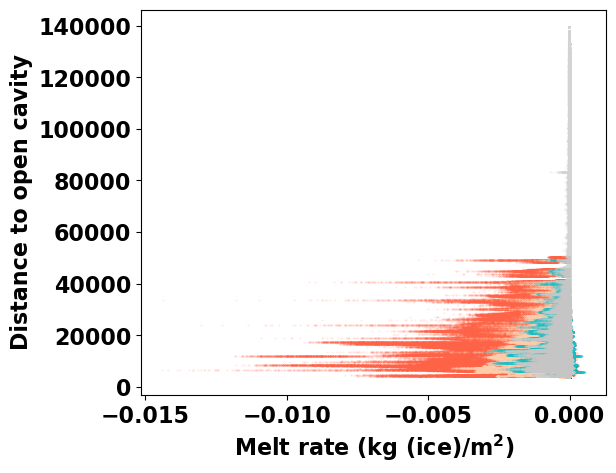

In [19]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_0.melt_m_ice_per_y, df_0.distances_GL, s = 0.1, alpha = 0.2, zorder = 10, color = 'C9')
    ax.scatter(df_1.melt_m_ice_per_y, df_1.distances_GL, s = 0.1, alpha = 0.2, zorder = 12, color = 'lightgrey')
    ax.scatter(df_2.melt_m_ice_per_y, df_2.distances_GL, s = 0.1, alpha = 0.2, color = 'tomato')
    ax.scatter(-df_3.melt_m_ice_per_y, df_3.distances_GL, s = 0.1, alpha = 0.2, color = 'peachpuff')
    ax.set_xlabel('Melt rate (kg (ice)/m$^2$)')
    ax.set_ylabel('Distance to open cavity')
    plt.show()

## **To look at the distribution of variables on a basin by basin basis**

In [20]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [21]:
# What do we want to show?
# We want to show that the difference between reference and predicted melt is correlated to 
# whether that data point falls into the training data set or not


In [22]:
# Firstly, we should import the applied dataset, and then calculate the difference between the reference and predicted melt 

In [9]:
from functions import load_test_data_whole_sim, load_model_nn, load_normalisation_metrics, regression_analysis, load_results_nn
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
df_26 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded


In [10]:
df_Ch = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded


In [25]:
sals = np.linspace(28,35.1,28)
temps = np.linspace(-3,8,44)
sals, temps = np.meshgrid(sals, temps)
rmse = np.zeros(sals.shape)
counts_d2 = np.zeros(sals.shape)
df_results = df_26
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_2.salinity_prop > sals[i,j]) & (df_2.salinity_prop < sals[i,j] + 0.25) & \
        (df_2.temperature_prop > temps[i,j]) & (df_2.temperature_prop < temps[i,j] + 0.25)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)
#im = plt.scatter(sals, temps, c = rmse)

In [26]:
sals = np.linspace(28,35.1,28)
temps = np.linspace(-3,8,44)
sals, temps = np.meshgrid(sals, temps)
#rmse = np.zeros(sals.shape)

In [27]:
counts = np.zeros(sals.shape)
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_0.salinity_prop > sals[i,j]) & (df_0.salinity_prop < sals[i,j] + 0.25) & \
        (df_0.temperature_prop > temps[i,j]) & (df_0.temperature_prop < temps[i,j] + 0.25)
    counts[i,j] = np.sum(mask)
counts1 = counts.copy()
counts1[counts1 == 0] = np.nan
counts1[counts1 > 0] = 1
counts2 = counts.copy()
counts2[counts2 == 0] = np.nan

counts_Ch = np.zeros(sals.shape)
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_3.salinity_prop > sals[i,j]) & (df_3.salinity_prop < sals[i,j] + 0.25) & \
        (df_3.temperature_prop > temps[i,j]) & (df_3.temperature_prop < temps[i,j] + 0.25)
    counts_Ch[i,j] = np.sum(mask)
counts1_Ch = counts_Ch.copy()
counts1_Ch[counts1_Ch == 0] = np.nan
counts1_Ch[counts1_Ch > 0] = 1
counts2_Ch = counts_Ch.copy()
counts2_Ch[counts2_Ch == 0] = np.nan

In [28]:
df_applied = df_2

In [29]:
plot_all = False
if plot_all == True:

    with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
        for i in range(18):
            fig, axs = plt.subplots(1,3, figsize = (18,5), width_ratios = (6,6,5))
            fig.subplots_adjust(wspace=0.2, hspace = 0.7)
            calls = 'df_26','df_Ch'
            for jj in range(len(calls)):
                if calls[jj] == 'df_26':
                    df_results = df_26
                elif calls[jj] == 'df_Ch':
                    df_results = df_Ch
                mask_results = np.in1d(df_results.basin, regions[i])
                df_basin = df_results[mask_results]
                df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
                # Get the mean input variables from the applied to dataset 
                mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
                df_basin_ap = df_applied[mask_applied]
                df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
                #plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
                #plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
                if calls[jj] == 'df_26':
                    diff = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
                elif calls[jj] == 'df_Ch':
                    diff = np.abs(-df_basinym.melt_Gt_per_y - df_basinym.melt_pred_Gt)
                
                im = axs[jj].scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                                 c = diff, zorder = 10)
                print(im.get_clim())
                print(np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
                im.set_clim(0,np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
                if jj == 0:
                    plt.colorbar(im, ax = axs[jj], label = 'Error in integrated melt (Gt/yr)', pad = 0.01, location = 'right')
                #ax[jj].scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
                axs[jj].set_ylim(-3,3)
                axs[jj].set_xlabel('Absolute salinity (g/kg)')
                axs[jj].set_ylabel('Conservative temperature ($^{{\\circ}}$C)')
            im = axs[0].pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
            im.set_clim(2,None)
            im = axs[1].pcolor(sals, temps, np.log10(counts2_Ch), cmap = 'Reds', alpha = 1)
            im.set_clim(2, None)
            cbar = plt.colorbar(im, ax = axs[1], location = 'left', label = 'Training data density', pad = 0.01)
            cbar.set_ticks((2,3,4,5,6))
            cbar.set_ticklabels(('10$^2$','10$^3$','10$^4$', '10$^5$', '10$^6$'))
            axs[1].yaxis.set_label_position("right")
            axs[1].yaxis.tick_right()
            labels = 'Trained on REF', 'Trained on MIDHOT'
            plt_labels = 'a)', 'b)', 'c)'
            for jj in range(2):
                axs[jj].annotate(labels[jj], xy = (0,0), xytext = (0.02,0.98), xycoords = 'axes fraction', va = 'top', ha = 'left')
            for j in range(3):    
                axs[jj].annotate(plt_labels[jj], xy = (0,0), xytext = (0.02,1.02), \
                                xycoords = 'axes fraction', va = 'bottom', ha = 'left', fontweight = 'normal')
            #ax[1].scatter(df_1.salinity_prop, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 3, color = 'peachpuff')
        
            ax = axs[2]
            for jj in range(len(calls)):
                if calls[jj] == 'df_26':
                    df_results = df_26
                elif calls[jj] == 'df_Ch':
                    df_results = df_Ch
                mask_results = np.in1d(df_results.basin, regions[i])
                df_basin = df_results[mask_results]
                df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
                if calls[jj] == 'df_26':
                    ax.plot(df_basinym.year*12, -df_basinym.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
                    ax.plot(df_basinym.year*12, -df_basinym.melt_pred_Gt, color = 'C9', label = 'Trained on REF')
                elif calls[jj] == 'df_Ch':
                    ax.plot(df_basinym.year*12, df_basinym.melt_pred_Gt, color = 'peachpuff', label = 'Trained on MIDHOT')
            ax.set_xlabel('Year')
            ax.set_ylabel('Integrated melt (Gt/yr)')
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ax.legend(loc = 2, fontsize = 10)
            
    #        plt.show()
            fig.savefig('In_training_range_{}.png'.format(str(i).zfill(2)), dpi = 200, bbox_inches = 'tight')

(1.2822619816110006, 178.01149730934475)
178.01149730934475
(1.0124448810674735, 51.550012039834996)
1103.5983248935415


/tmp/ipykernel_3731992/3538213998.py:40: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax = axs[1], location = 'left', label = 'Training data density', pad = 0.01)


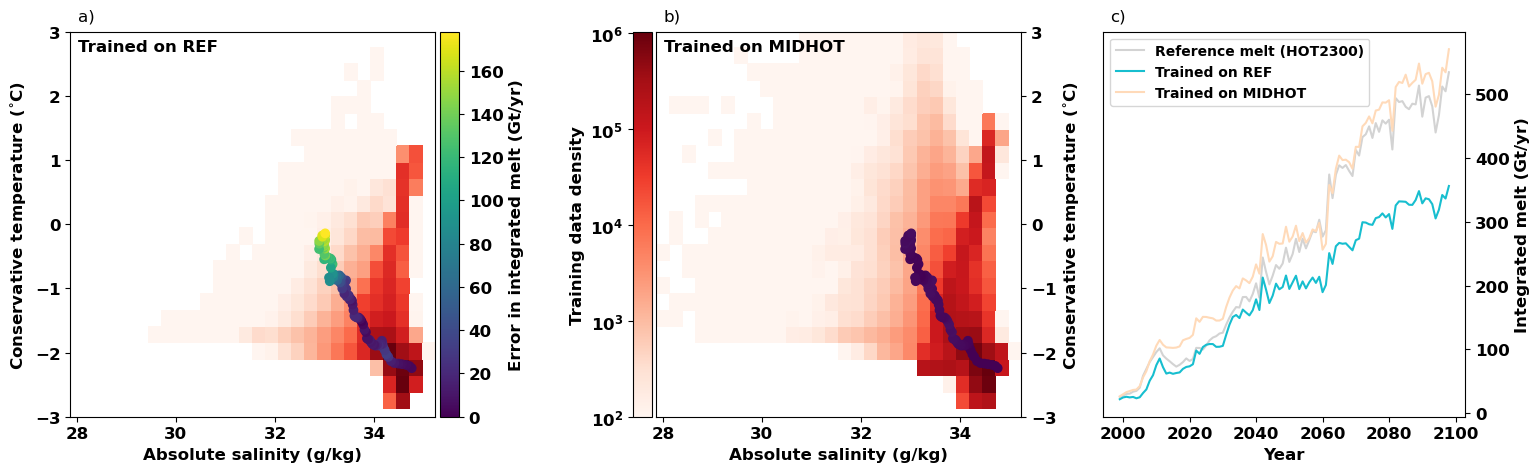

In [30]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,3, figsize = (18,5), width_ratios = (6,6,5))
    fig.subplots_adjust(wspace=0.2, hspace = 0.7)
    i = 17 #6,10,12,14,17 but 13 and 5
    calls = 'df_26','df_Ch'
    for jj in range(len(calls)):
        if calls[jj] == 'df_26':
            df_results = df_26
        elif calls[jj] == 'df_Ch':
            df_results = df_Ch
        mask_results = np.in1d(df_results.basin, regions[i])
        df_basin = df_results[mask_results]
        df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
        # Get the mean input variables from the applied to dataset 
        mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
        df_basin_ap = df_applied[mask_applied]
        df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
        #plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
        #plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
        if calls[jj] == 'df_26':
            diff = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
        elif calls[jj] == 'df_Ch':
            diff = np.abs(-df_basinym.melt_Gt_per_y - df_basinym.melt_pred_Gt)
        
        im = axs[jj].scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                         c = diff, zorder = 10)
        print(im.get_clim())
        print(np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
        im.set_clim(0,np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
        if jj == 0:
            plt.colorbar(im, ax = axs[jj], label = 'Error in integrated melt (Gt/yr)', pad = 0.01, location = 'right')
        #ax[jj].scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
        axs[jj].set_ylim(-3,3)
        axs[jj].set_xlabel('Absolute salinity (g/kg)')
        axs[jj].set_ylabel('Conservative temperature ($^{{\\circ}}$C)')
    im = axs[0].pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
    im.set_clim(2,None)
    im = axs[1].pcolor(sals, temps, np.log10(counts2_Ch), cmap = 'Reds', alpha = 1)
    im.set_clim(2, None)
    cbar = plt.colorbar(im, ax = axs[1], location = 'left', label = 'Training data density', pad = 0.01)
    cbar.set_ticks((2,3,4,5,6))
    cbar.set_ticklabels(('10$^2$','10$^3$','10$^4$', '10$^5$', '10$^6$'))
    axs[1].yaxis.set_label_position("right")
    axs[1].yaxis.tick_right()
    labels = 'Trained on REF', 'Trained on MIDHOT'
    plt_labels = 'a)', 'b)', 'c)'
    for jj in range(2):
        axs[jj].annotate(labels[jj], xy = (0,0), xytext = (0.02,0.98), xycoords = 'axes fraction', va = 'top', ha = 'left')
    for jj in range(3):    
        axs[jj].annotate(plt_labels[jj], xy = (0,0), xytext = (0.02,1.02), \
                        xycoords = 'axes fraction', va = 'bottom', ha = 'left', fontweight = 'normal')
    #ax[1].scatter(df_1.salinity_prop, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 3, color = 'peachpuff')

    ax = axs[2]
    for jj in range(len(calls)):
        if calls[jj] == 'df_26':
            df_results = df_26
        elif calls[jj] == 'df_Ch':
            df_results = df_Ch
        mask_results = np.in1d(df_results.basin, regions[i])
        df_basin = df_results[mask_results]
        df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
        if calls[jj] == 'df_26':
            ax.plot(df_basinym.year*12, -df_basinym.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
            ax.plot(df_basinym.year*12, -df_basinym.melt_pred_Gt, color = 'C9', label = 'Trained on REF')
        elif calls[jj] == 'df_Ch':
            ax.plot(df_basinym.year*12, df_basinym.melt_pred_Gt, color = 'peachpuff', label = 'Trained on MIDHOT')
    ax.set_xlabel('Year')
    ax.set_ylabel('Integrated melt (Gt/yr)')
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.legend(loc = 2, fontsize = 10)
    
    plt.show()
    fig.savefig('In_training_range_{}.png'.format(str(i).zfill(2)), dpi = 200, bbox_inches = 'tight')

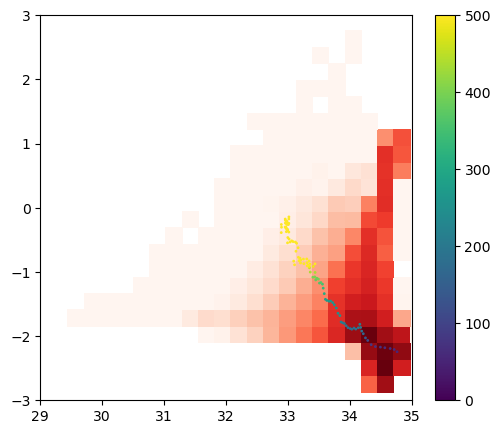

In [31]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
i = 17
mask_results = np.in1d(df_results.basin, regions[i])
df_basin = df_results[mask_results]
df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
# Get the mean input variables from the applied to dataset 
mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
df_basin_ap = df_applied[mask_applied]
df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
#plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
#plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
im = plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                 c = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt), zorder = 10, s = 1)
#print(np.min(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt), np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
im.set_clim(0,500)
plt.colorbar(im)
#ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
im = ax.pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
im.set_clim(2,None)
ax.set_ylim(-3,3)
ax.set_xlim(29,35)
plt.show()


151.41354231099413 0.5622547306957983
288.21915621171604 1.581374535762734
71.68548912029902 0.9075887837050445
828.5476258915887 2.6394428577061575
173.97287342592898 1.4762042923555896
139.2107754423269 5.728034034719059
93.40247815071362 5.008626053715602
35.17088553635629 2.838227340183984
39.74767096239359 0.05274373875441185
202.31031580360371 2.994361684992441
507.897480470446 3.0139350483559895
339.3986443890333 4.736486649621156
52.3767196051957 2.164110356546203
255.47430135147664 3.364459133574883
90.54748208480937 9.526516719842526
86.85174628970107 20.993808381675784
211.92697845316806 0.027928335462235054
178.01149730934475 1.2822619816110006


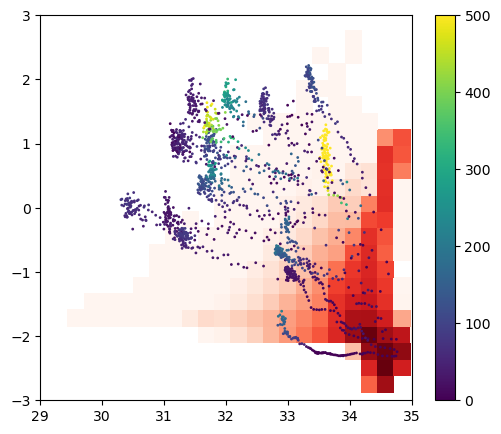

In [32]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
df_results = df_26
for i in range(18):
    mask_results = np.in1d(df_results.basin, regions[i])
    df_basin = df_results[mask_results]
    df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
    # Get the mean input variables from the applied to dataset 
    mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
    df_basin_ap = df_applied[mask_applied]
    df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
#plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
#plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
    #im = plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
    #                 c = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt), zorder = 10, s = 1)
    error_Gt = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
    max_error_Gt = max(error_Gt)
    min_error_Gt = min(error_Gt)
    print(max_error_Gt, min_error_Gt)
    im = plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                     c = error_Gt, zorder = 10, s = 1)
    im.set_clim(0,500)
plt.colorbar(im)
#ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
im = ax.pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
im.set_clim(2,None)
ax.set_ylim(-3,3)
ax.set_xlim(29,35)
plt.show()


In [33]:
df_results = df_26
df_applied = df_2
# Get the results of applying to the basin
mask_results = np.in1d(df_results.basin, regions[i])
df_basin = df_results[mask_results]
df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
# Get the mean input variables from the applied to dataset 
mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
df_basin_ap = df_applied[mask_applied]
df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
euc = np.sqrt((df_apym.salinity_prop - df_0.salinity_prop.mean())**2 +  (df_apym.temperature_prop - df_0.temperature_prop.mean()) ** 2)

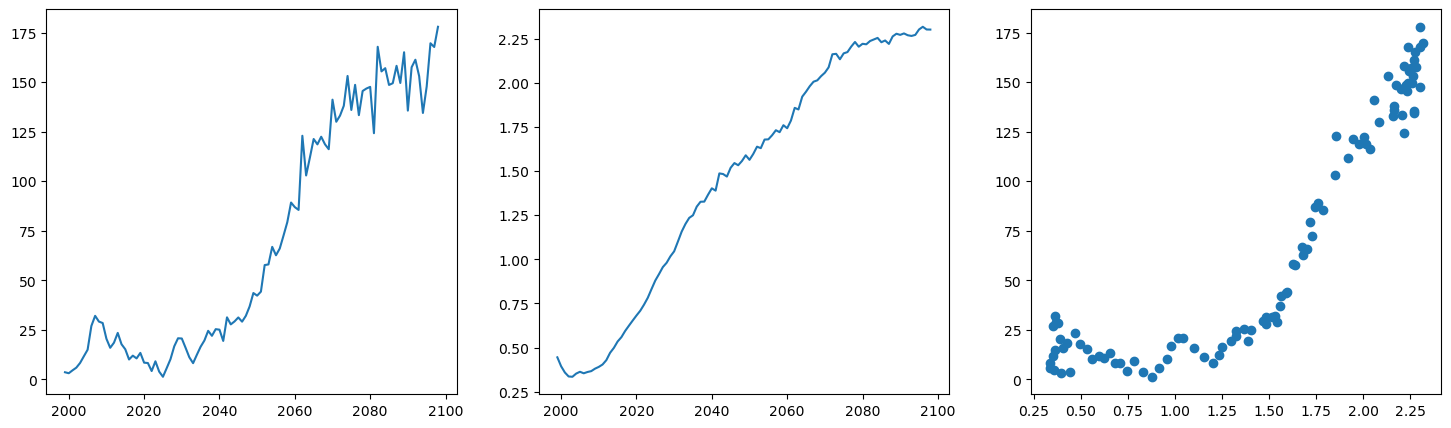

In [34]:
fig, axs = plt.subplots(1,3, figsize = (18,5))
axs[0].plot(df_basinym.year*12 , np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))#, s = 0.1)
axs[1].plot(df_apym.year, euc)
axs[2].scatter(euc, np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
regression_analysis(euc, np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
plt.show()

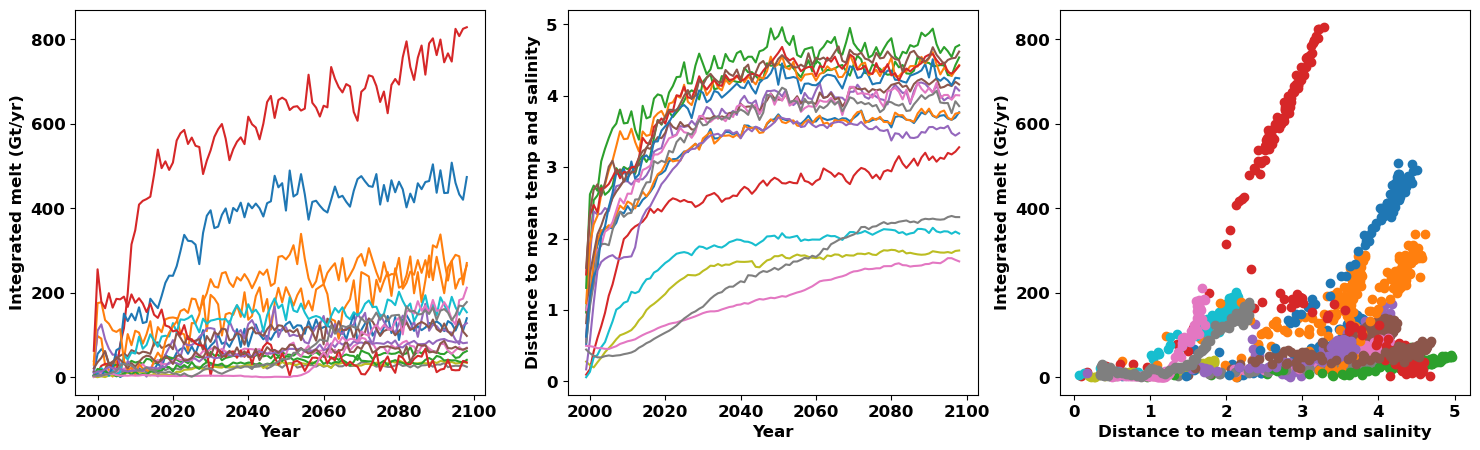

In [35]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    df_results = df_26
    fig, axs = plt.subplots(1,3, figsize = (18,5))
    for i in range(18):
        mask_results = np.in1d(df_results.basin, regions[i])
        df_basin = df_results[mask_results]
        df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
        # Get the mean input variables from the applied to dataset 
        mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
        df_basin_ap = df_applied[mask_applied]
        df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
        euc = np.sqrt((df_apym.salinity_prop - df_0.salinity_prop.mean())**2 +  (df_apym.temperature_prop - df_0.temperature_prop.mean()) ** 2)
        error_Gt = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
        axs[0].plot(df_basinym.year*12 , error_Gt)#, s = 0.1)
        axs[1].plot(df_apym.year, euc)
        axs[2].scatter(euc, error_Gt)
    axs[0].set_ylabel('Integrated melt (Gt/yr)')
    axs[0].set_xlabel('Year')
    axs[1].set_ylabel('Distance to mean temp and salinity')
    axs[1].set_xlabel('Year')
    axs[2].set_ylabel('Integrated melt (Gt/yr)')
    axs[2].set_xlabel('Distance to mean temp and salinity')
    plt.show()

In [36]:
eucall = np.sqrt((df_2.salinity_prop - df_0.salinity_prop.mean())**2 +  (df_2.temperature_prop - df_0.temperature_prop.mean()) ** 2)
    

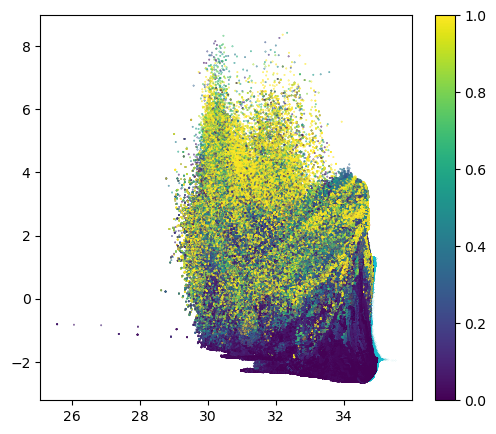

In [37]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
df_results = df_26
im = ax.scatter(df_2.salinity_prop, df_2.temperature_prop, c = np.abs(df_results.melt_Gt_per_y - df_results.melt_pred_Gt), s = 0.1)
plt.colorbar(im)
im.set_clim(0,1)
ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.01, alpha = 0.2, zorder = 0, color = 'C9')
plt.show()


In [11]:
sals = np.linspace(28,35,29)
temps = np.linspace(-3,8,45)
sals, temps = np.meshgrid(sals, temps)
rmse = np.zeros(sals.shape)
counts_d2 = np.zeros(sals.shape)
df_results = df_26
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 45*29, 'processing', end = '\r')
    mask = (df_2.salinity_prop > sals[i,j]) & (df_2.salinity_prop < sals[i,j] + 0.25) & \
        (df_2.temperature_prop > temps[i,j]) & (df_2.temperature_prop < temps[i,j] + 0.25)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)
#im = plt.scatter(sals, temps, c = rmse)

In [41]:
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

In [13]:
df2_point = df_2[df_2.year > 2088].groupby(['lat','lon'], as_index = False).mean()

In [14]:
df2_pointsCh = df_2.groupby(['lat','lon', 'year', 'month'], as_index = False).mean()

In [15]:
dfCh_points = df_Ch.groupby(['lat','lon', 'year', 'month'], as_index = False).mean()

In [77]:
sals = np.linspace(28,35,29)
temps = np.linspace(-3,8,45)
sals, temps = np.meshgrid(sals, temps)
rmse_Ch = np.zeros(sals.shape)
counts_Ch = np.zeros(sals.shape)
df_results = dfCh_points
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 45*29, 'processing', end = '\r')
    mask = (df2_pointsCh.salinity_prop > sals[i,j]) & (df2_pointsCh.salinity_prop < sals[i,j] + 0.25) & \
        (df2_pointsCh.temperature_prop > temps[i,j]) & (df2_pointsCh.temperature_prop < temps[i,j] + 0.25)
    rmse_Ch[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y + df_results[mask].melt_pred_mean)**2))
    counts_Ch[i,j] = np.sum(mask)
#im = plt.scatter(sals, temps, c = rmse)

In [8]:
sals = np.linspace(28,35,29)
temps = np.linspace(-3,8,45)
sals, temps = np.meshgrid(sals, temps)
counts_d3 = np.zeros(sals.shape)
df_results = df_3
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 45*29, 'processing', end = '\r')
    mask = (df_results.salinity_prop > sals[i,j]) & (df_results.salinity_prop < sals[i,j] + 0.25) & \
        (df_results.temperature_prop > temps[i,j]) & (df_results.temperature_prop < temps[i,j] + 0.25)
    counts_d3[i,j] = np.sum(mask)

In [9]:
sals = np.linspace(28,35,29)
temps = np.linspace(-3,8,45)
sals, temps = np.meshgrid(sals, temps)
counts_d2 = np.zeros(sals.shape)
df_results = df_2
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 45*29, 'processing', end = '\r')
    mask = (df_results.salinity_prop > sals[i,j]) & (df_results.salinity_prop < sals[i,j] + 0.25) & \
        (df_results.temperature_prop > temps[i,j]) & (df_results.temperature_prop < temps[i,j] + 0.25)
    counts_d2[i,j] = np.sum(mask)

In [10]:
sals = np.linspace(28,35,29)
temps = np.linspace(-3,8,45)
sals, temps = np.meshgrid(sals, temps)
counts_d0 = np.zeros(sals.shape)
df_results = df_0
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 45*29, 'processing', end = '\r')
    mask = (df_results.salinity_prop > sals[i,j]) & (df_results.salinity_prop < sals[i,j] + 0.25) & \
        (df_results.temperature_prop > temps[i,j]) & (df_results.temperature_prop < temps[i,j] + 0.25)
    counts_d0[i,j] = np.sum(mask)

In [11]:
sals = np.linspace(28,35,29)
temps = np.linspace(-3,8,45)
sals, temps = np.meshgrid(sals, temps)
counts_d1 = np.zeros(sals.shape)
df_results = df_1
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 45*29, 'processing', end = '\r')
    mask = (df_results.salinity_prop > sals[i,j]) & (df_results.salinity_prop < sals[i,j] + 0.25) & \
        (df_results.temperature_prop > temps[i,j]) & (df_results.temperature_prop < temps[i,j] + 0.25)
    counts_d1[i,j] = np.sum(mask)

In [17]:
counts_d0[counts_d0 == 0] = np.nan
counts_d0
counts_d2[counts_d2 == 0] = np.nan
counts_d2
counts_d3[counts_d3 == 0] = np.nan
counts_d3
counts_d1[counts_d1 == 0] = np.nan
counts_d1

array([[    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [    nan,     nan,     nan, ...,  46181., 180527.,     nan],
       ...,
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [    nan,     nan,     nan, ...,     nan,     nan,     nan]])

In [17]:
fp_data = 'Figure_data/'
np.savetxt(fp_data + 'sals.csv', sals, delimiter = ',')
np.savetxt(fp_data + 'temps.csv', temps, delimiter = ',')
np.savetxt(fp_data + 'rmse.csv', rmse, delimiter = ',')
np.savetxt(fp_data + 'rmse_Ch.csv', rmse_Ch, delimiter = ',')

df2_point.to_csv(fp_data + 'df2_point.csv')

In [18]:
fp_data = 'Figure_data/'
np.savetxt(fp_data + 'counts_d0.csv', counts_d0, delimiter = ',')
np.savetxt(fp_data + 'counts_d1.csv', counts_d1, delimiter = ',')
np.savetxt(fp_data + 'counts_d2.csv', counts_d2, delimiter = ',')
np.savetxt(fp_data + 'counts_d3.csv', counts_d3, delimiter = ',')

In [19]:
sals = np.loadtxt(fp_data + 'sals.csv', delimiter = ',')
temps = np.loadtxt(fp_data + 'temps.csv', delimiter = ',')
rmse = np.loadtxt(fp_data + 'rmse.csv', delimiter = ',')
rmse_Ch = np.loadtxt(fp_data + 'rmse_Ch.csv', delimiter = ',')

counts_d0 = np.loadtxt(fp_data + 'counts_d0.csv', delimiter = ',')
counts_d1 = np.loadtxt(fp_data + 'counts_d1.csv', delimiter = ',')
counts_d2 = np.loadtxt(fp_data + 'counts_d2.csv', delimiter = ',')
counts_d3 = np.loadtxt(fp_data + 'counts_d3.csv', delimiter = ',')

df2_point = pd.read_csv(fp_data + 'df2_point.csv')

/tmp/ipykernel_2894760/915269929.py:24: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax=axs[i], boundaries = boundaries, extend = 'max', orientation = 'horizontal')
/tmp/ipykernel_2894760/915269929.py:25: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  im[i].set_clim(-1,6)
/tmp/ipykernel_2894760/915269929.py:24: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax=axs[i], boundaries = boundaries, extend = 'max', orientation = 'horizontal')
/tmp/ipykernel_289

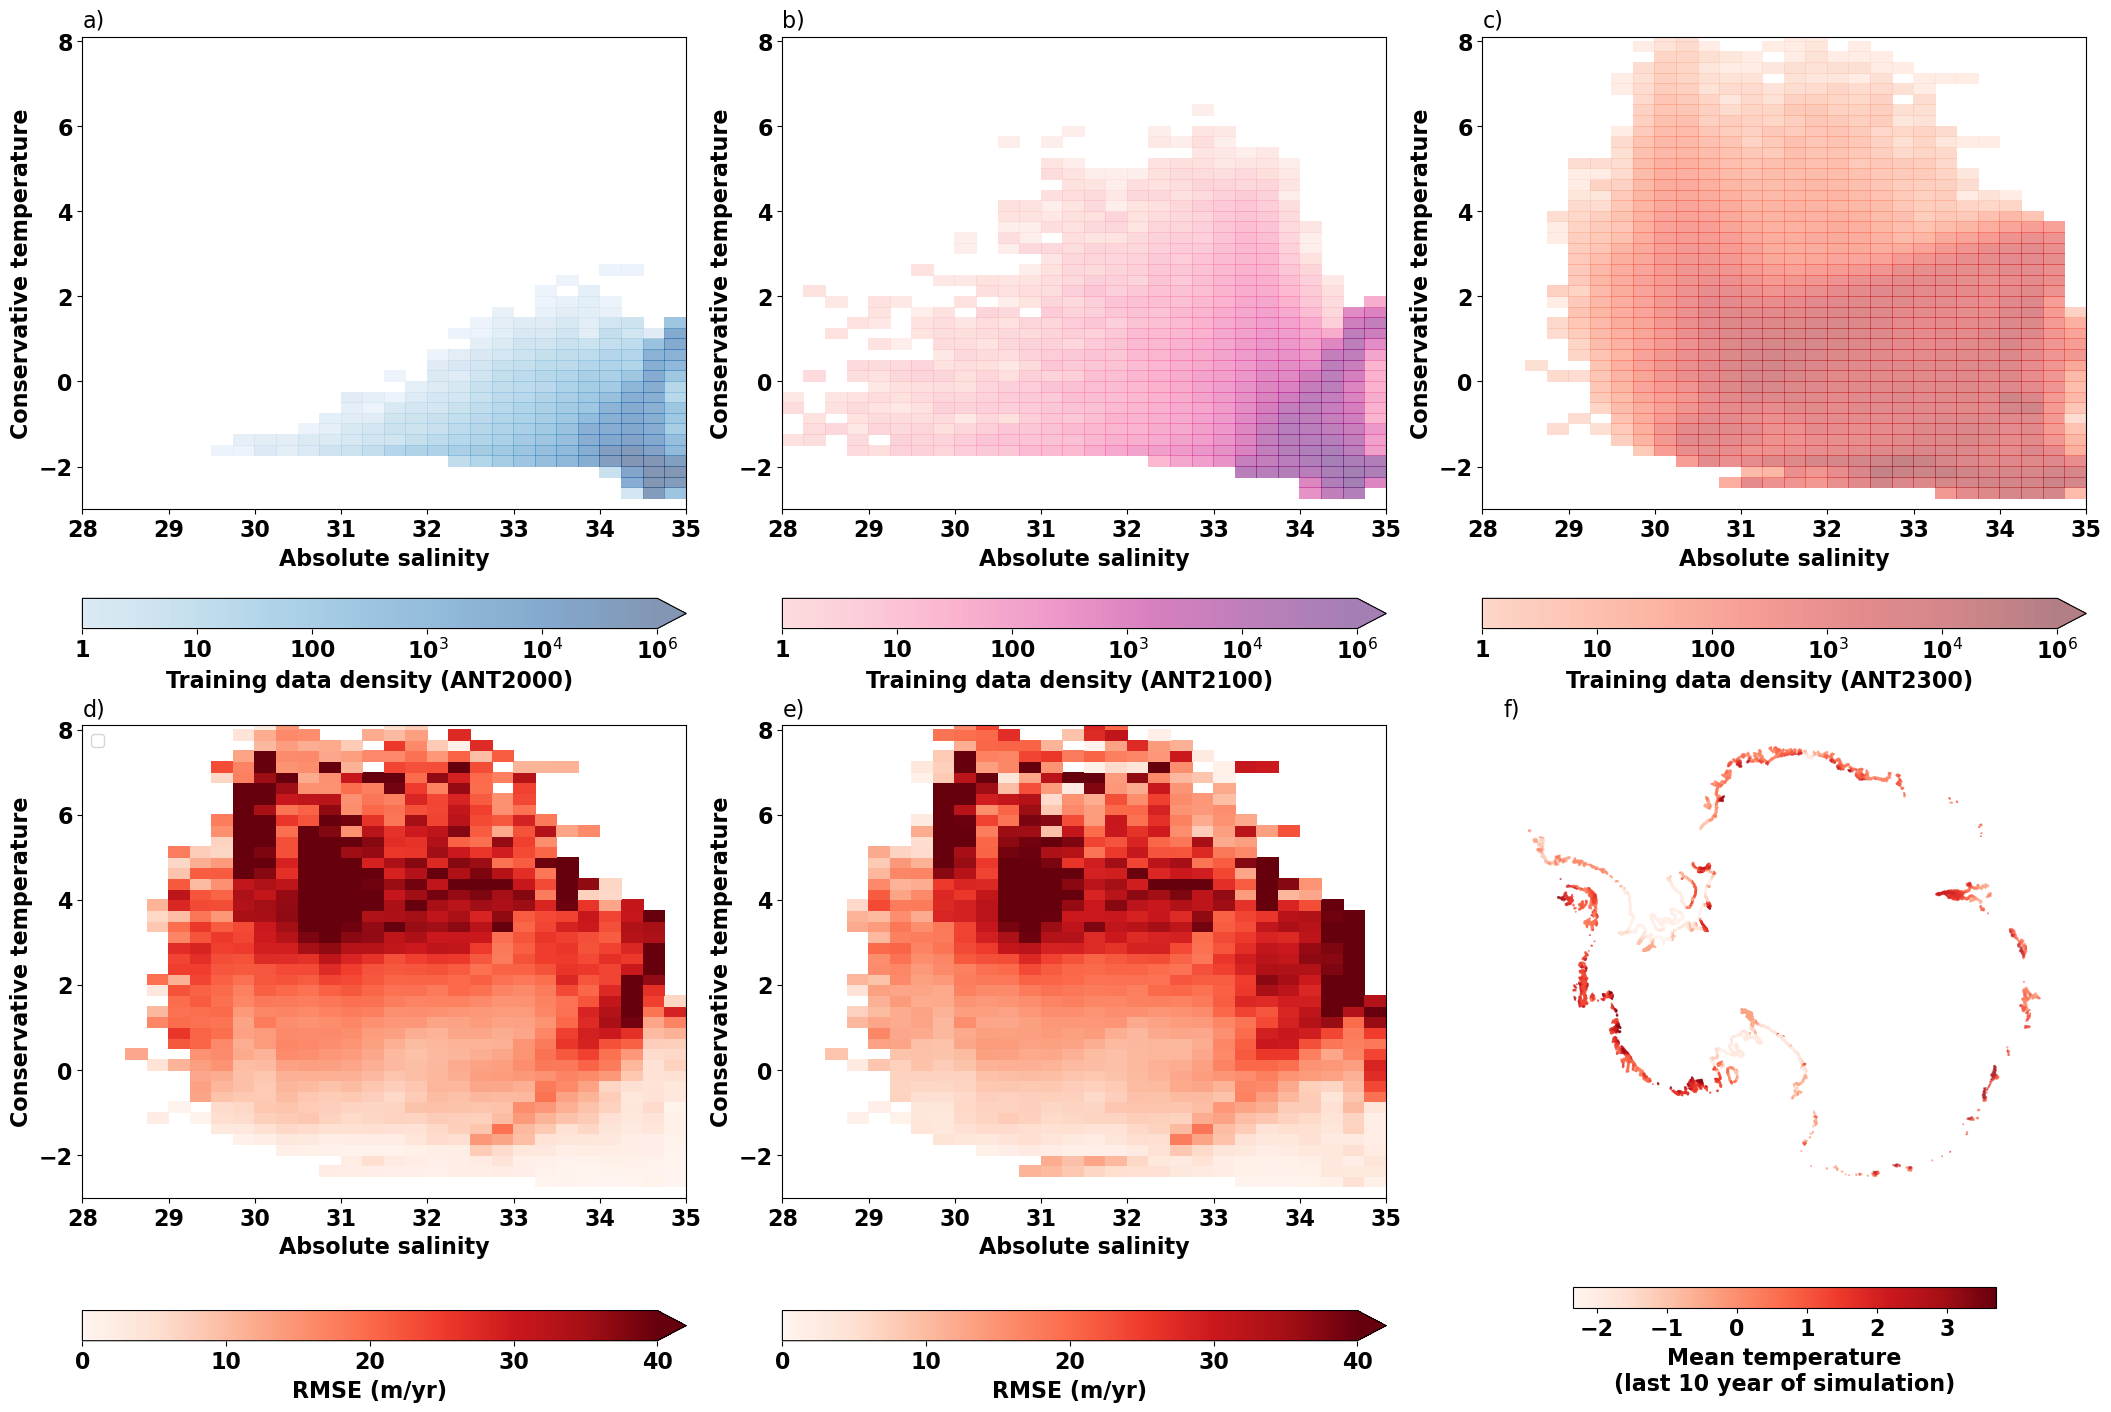

In [74]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig = plt.figure(constrained_layout=True, figsize = (21,14))
    gs = fig.add_gridspec(2,3, width_ratios = (6,6,6), wspace = -1)
    axs = [[],[],[],[],[],[],[],[]]
    axs[0] = fig.add_subplot(gs[0,0])
    axs[1] = fig.add_subplot(gs[0,1])
    axs[2] = fig.add_subplot(gs[0,2])
    axs[3] = fig.add_subplot(gs[1,0])
    axs[4] = fig.add_subplot(gs[1,1])
    axs[5] = fig.add_subplot(gs[1,2], projection = proj)
    gs.update(wspace=0, hspace = 0)
    
    im= [[],[],[]]
    ax = axs[0]
    im[0] = ax.pcolor(sals+0.125, temps+0.125, np.log10(counts_d0), cmap = 'Blues', alpha = 0.5)
    ax = axs[1]
    im[1] = ax.pcolor(sals+0.125, temps+0.125, np.log10(counts_d3), cmap = 'RdPu', alpha = 0.5)
    ax = axs[2]
    im[2] = ax.pcolor(sals+0.125, temps+0.125, np.log10(counts_d2), cmap = 'Reds', alpha = 0.5)

    simulation = '(ANT2000)', '(ANT2100)', '(ANT2300)'
    for i in range(3):
        boundaries = np.linspace(1,6,100)
        cbar = plt.colorbar(im[i], ax=axs[i], boundaries = boundaries, extend = 'max', orientation = 'horizontal')
        im[i].set_clim(-1,6)
        cbar.set_ticks((1,2,3,4,5,6))
        cbar.set_ticklabels(('1','10','100', '10$^3$', '10$^4$', '10$^6$'))  
        cbar.set_label('Training data density ' + simulation[i])

    ax = axs[3]
    im3 = ax.pcolor(sals+0.125, temps+0.125, rmse*(31536000/917), cmap = 'Reds', zorder = 0)
    ax.legend(loc = 2, markerscale = 50, fontsize = 12)
    for i in range(5):
        axs[i].set_xlabel('Absolute salinity')
        axs[i].set_ylabel('Conservative temperature')
        axs[i].set_xlim(28,35)
        axs[i].set_ylim(-3,8.1)
    im3.set_clim(0,40)
    cbar = plt.colorbar(im3, ax = ax, pad = 0.1, label = 'RMSE (m/yr)', extend = 'max', orientation = 'horizontal')
    cbar.set_ticks((0,10,20,30,40))
    cbar.set_ticklabels(('0','10','20','30','40'))

    ax = axs[4]
    im3 = ax.pcolor(sals+0.125, temps+0.125, rmse_Ch*(31536000/917), cmap = 'Reds', zorder = 0)
    for i in range(5):
        axs[i].set_xlabel('Absolute salinity')
        axs[i].set_ylabel('Conservative temperature')
        axs[i].set_xlim(28,35)
        axs[i].set_ylim(-3,8.1)
    im3.set_clim(0,40)
    cbar = plt.colorbar(im3, ax = ax, pad = 0.1, label = 'RMSE (m/yr)', extend = 'max', orientation = 'horizontal')
    cbar.set_ticks((0,10,20,30,40))
    cbar.set_ticklabels(('0','10','20','30','40'))

    ax = axs[5]
    im = ax.scatter(df2_point.lon, df2_point.lat, c = df2_point.temperature_prop, cmap = 'Reds', transform = trans, s = 0.1)
    cbar = plt.colorbar(im, ax = ax, shrink = 0.7, orientation = 'horizontal')
    cbar.set_label('Mean temperature\n(last 10 year of simulation)') 
    ax.axis('off')

    plt_labels = 'a)', 'b)', 'c)', 'd)', 'e)', 'f)'
    for i in range(6):
        axs[i].annotate(plt_labels[i], xy = (0,0), xytext = (0,1.02), xycoords = 'axes fraction', fontweight = 'normal')
    
    #plt.show()
    #fig.savefig('FIGURES/TandS_ranges.png', dpi = 200, bbox_inches = 'tight')

/tmp/ipykernel_3206810/2546354745.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im)
/tmp/ipykernel_3206810/2546354745.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.clim(0,0)


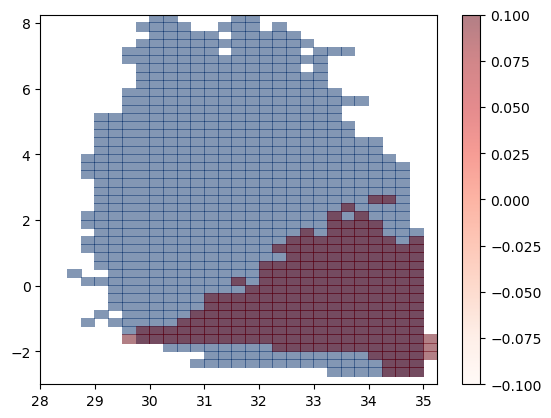

In [41]:
im = plt.pcolor(sals+0.125, temps+0.125, counts_d2, cmap = 'Blues_r', alpha = 0.5)
plt.clim(0,0)
im = plt.pcolor(sals+0.125, temps+0.125, counts_d0, cmap = 'Reds', alpha = 0.5)
plt.colorbar(im)
plt.clim(0,0)

In [13]:
df0_latlon_min = df_0.groupby(['lat','lon'], as_index = False).min()
df0_latlon_max = df_0.groupby(['lat','lon'], as_index = False).max()

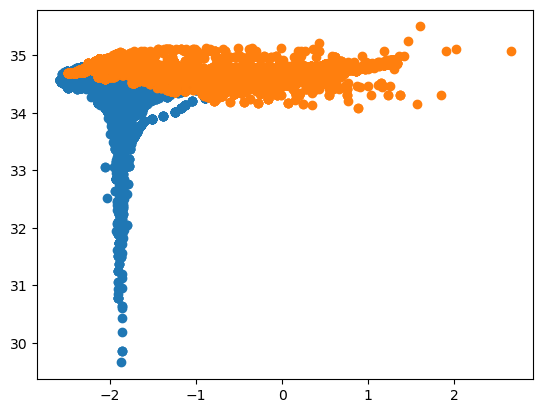

In [14]:
plt.scatter(df0_latlon_min.temperature_prop, df0_latlon_min.salinity_prop)
plt.scatter(df0_latlon_max.temperature_prop, df0_latlon_max.salinity_prop)

/tmp/ipykernel_3798163/3766056016.py:29: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[0], ax = axs[2], pad = 0.1, label = 'RMSE (m/yr)')
/tmp/ipykernel_3798163/3766056016.py:61: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[0], ax = axs[6], pad = 0.1, label = 'RMSE (m/yr)')


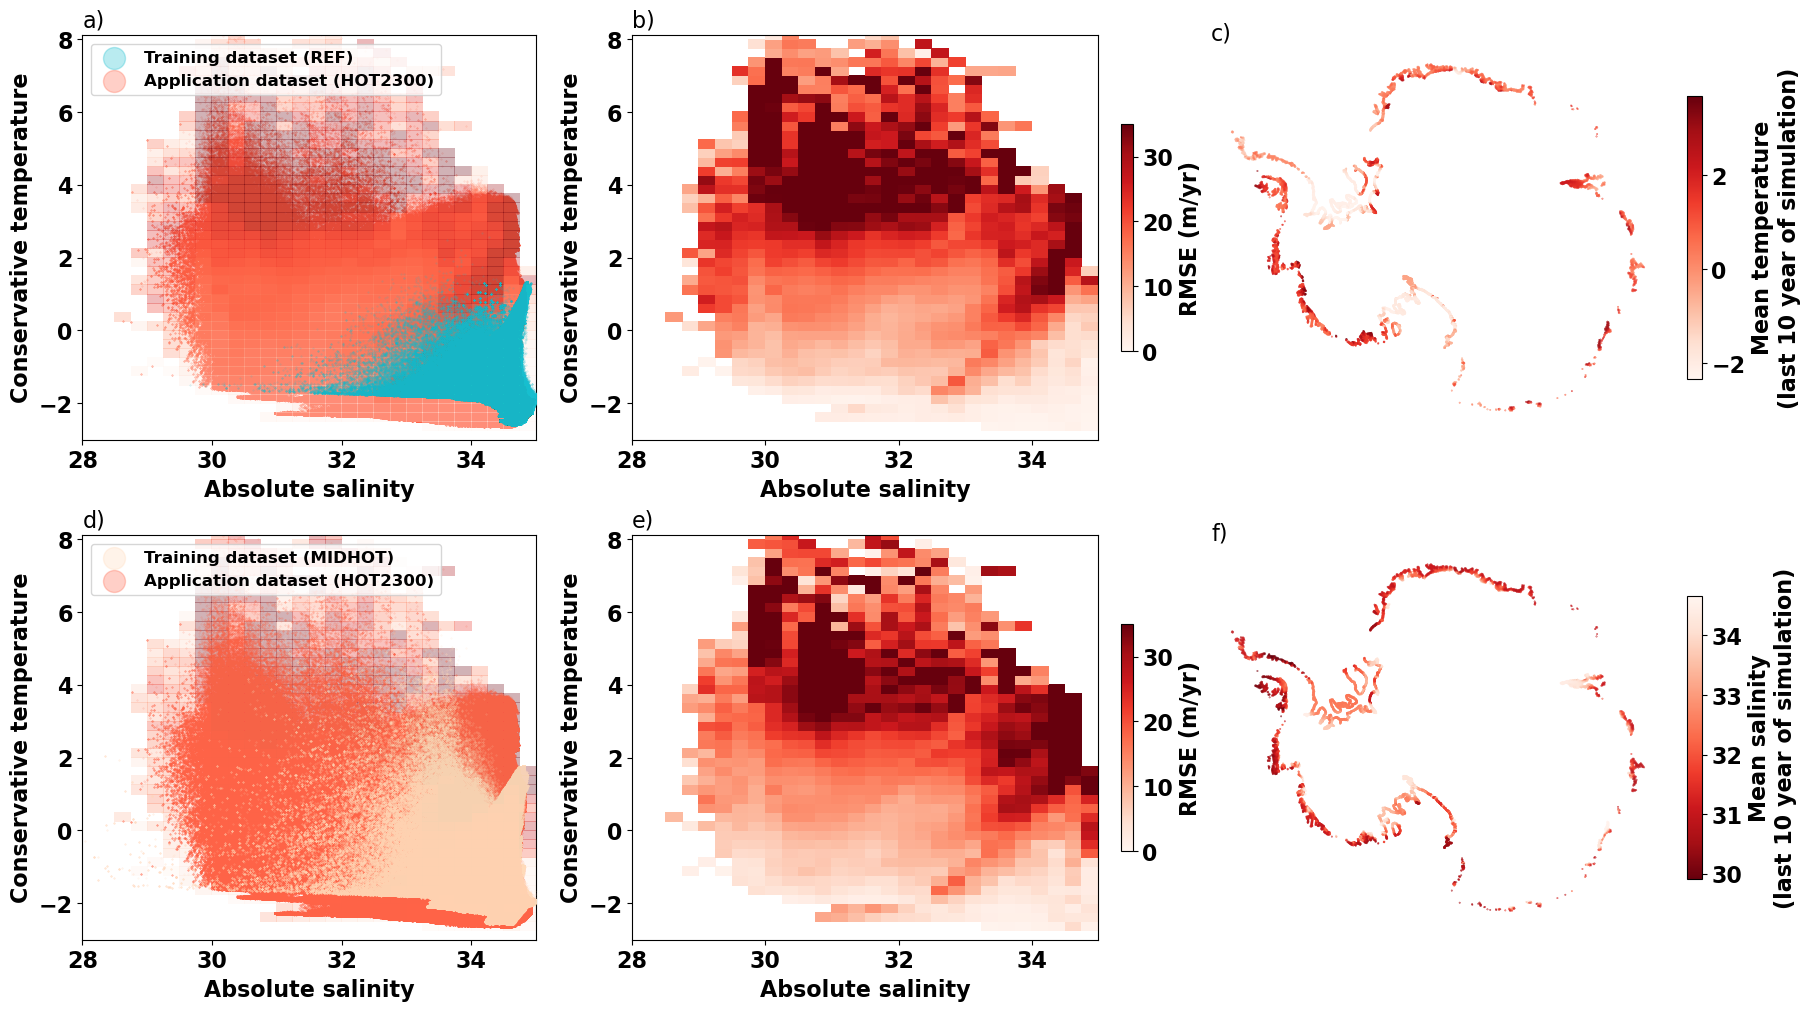

In [36]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig = plt.figure(constrained_layout=True, figsize = (18,10))
    gs = fig.add_gridspec(2,4, width_ratios = (6,5,1,6), wspace = -1)
    axs = [[],[],[],[],[],[],[],[]]
    axs[0] = fig.add_subplot(gs[0,0])
    axs[1] = fig.add_subplot(gs[0,1:3])
    axs[2] = fig.add_subplot(gs[0,2])
    axs[3] = fig.add_subplot(gs[0,3], projection = proj)
    axs[4] = fig.add_subplot(gs[1,0])
    axs[5] = fig.add_subplot(gs[1,1:3])
    axs[6] = fig.add_subplot(gs[1,2])
    axs[7] = fig.add_subplot(gs[1,3], projection = proj)
    gs.update(wspace=0, hspace = 0)

    axs[0].scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.3, zorder = 5, color = 'C9', \
                  label = 'Training dataset (REF)')
    axs[0].scatter(df_2.salinity_prop, df_2.temperature_prop, s = 0.1, alpha = 0.3, zorder = 0, color = 'tomato', \
                  label = 'Application dataset (HOT2300)')
    im = [[],[]]
    im[0] = axs[1].pcolor(sals+0.125, temps+0.125, rmse*(31536000/917), cmap = 'Reds', zorder = 0)
    im[1] = axs[0].pcolor(sals+0.125, temps+0.125, rmse*(31536000/917), cmap = 'Reds', zorder = 0, alpha =0.3)
    axs[0].legend(loc = 2, markerscale = 50, fontsize = 12)
    for i in range(2):
        axs[i].set_xlabel('Absolute salinity')
        axs[i].set_ylabel('Conservative temperature')
        axs[i].set_xlim(28,35)
        axs[i].set_ylim(-3,8.1)
        im[i].set_clim(0,35)
    cbar = plt.colorbar(im[0], ax = axs[2], pad = 0.1, label = 'RMSE (m/yr)')
    cbar.set_ticks((0,10,20,30))
    cbar.set_ticklabels(('0','10','20','30'))
    #axs[0].yaxis.tick_right()
    #axs[0].set_yticklabels(('','','','',''))
    #axs[0].set_ylabel('')
    axs[2].axis('off')

    im = axs[3].scatter(df2_point.lon, df2_point.lat, c = df2_point.temperature_prop, cmap = 'Reds', transform = trans, s = 0.1)
    #im.set_clim(0,0.02)
    cbar = plt.colorbar(im, shrink = 0.7)
    cbar.set_label('Mean temperature\n(last 10 year of simulation)') 
    axs[3].axis('off')

    plt_labels = 'a)', 'b)', 'c)', 'c)'
    for i in (0,1,3):
        axs[i].annotate(plt_labels[i], xy = (0,0), xytext = (0,1.02), xycoords = 'axes fraction', fontweight = 'normal')

    axs[4].scatter(df_3.salinity_prop, df_3.temperature_prop, s = 0.1, alpha = 0.3, zorder = 5, color = 'peachpuff', \
                  label = 'Training dataset (MIDHOT)')
    axs[4].scatter(df_2.salinity_prop, df_2.temperature_prop, s = 0.1, alpha = 0.3, zorder = 2, color = 'tomato', \
                  label = 'Application dataset (HOT2300)')
    im = [[],[]]
    im[0] = axs[5].pcolor(sals+0.125, temps+0.125, rmse_Ch*(31536000/917), cmap = 'Reds', zorder = 0)
    im[1] = axs[4].pcolor(sals+0.125, temps+0.125, rmse_Ch*(31536000/917), cmap = 'Reds', zorder = 0, alpha =0.3)
    axs[4].legend(loc = 2, markerscale = 50, fontsize = 12)
    for i in range(2):
        axs[i+4].set_xlabel('Absolute salinity')
        axs[i+4].set_ylabel('Conservative temperature')
        axs[i+4].set_xlim(28,35)
        axs[i+4].set_ylim(-3,8.1)
        im[i].set_clim(0,35)
    cbar = plt.colorbar(im[0], ax = axs[6], pad = 0.1, label = 'RMSE (m/yr)')
    cbar.set_ticks((0,10,20,30))
    cbar.set_ticklabels(('0','10','20','30'))
    #axs[4].yaxis.tick_right()
    #axs[4].set_yticklabels(('','','','',''))
    #axs[4].set_ylabel('')
    axs[6].axis('off')

    im = axs[7].scatter(df2_point.lon, df2_point.lat, c = df2_point.salinity_prop, cmap = 'Reds_r', transform = trans, s = 0.1)
    #im.set_clim(0,0.02)
    cbar = plt.colorbar(im, shrink = 0.7)
    cbar.set_label('Mean salinity\n(last 10 year of simulation)') 
    axs[7].axis('off')

    plt_labels = 'd)', 'e)', 'f)', 'f)'
    for i in (0,1,3):
        axs[i+4].annotate(plt_labels[i], xy = (0,0), xytext = (0,1.02), xycoords = 'axes fraction', fontweight = 'normal')
    
    plt.show()
    fig.savefig('FIGURES/TandS_ranges.png', dpi = 200, bbox_inches = 'tight')

In [45]:
purple

NameError: name 'purple' is not defined

## **To look at T and S by basin**

In [ ]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [ ]:
df_2.columns

In [ ]:
fig, ax  = plt.subplots(1,2, figsize = (12,5))
df_applied = df_2
ax[0].pcolor(sals, temps, counts2, cmap = 'Reds')
ax[1].pcolor(sals, temps, counts2_Ch, cmap = 'Reds')
for i in (5,10,13):
    mask_results = np.in1d(df_applied.basins_NEMO, regions[i])
    df_basin = df_applied[mask_results]
    ax[0].scatter(df_basin.salinity_prop, df_basin.temperature_prop, s = 0.1, alpha = 0.1)
plt.show()

In [ ]:
df_applied = df_2
i = 17
mask_results = np.in1d(df_applied.basins_NEMO, regions[i])
df_basin = df_applied[mask_results]

In [ ]:
plt.scatter(df_basin.salinity_prop, df_basin.temperature_prop, s = 0.1, alpha = 0.2)
plt.show()

In [ ]:
df_26on263 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM0263_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

In [ ]:
250000/25

In [ ]:
isf = 100
dist = 50000
mask = (df_1.corrected_isfdraft > isf) & (df_results.corrected_isdraft < isf + 100) & \
        (df_results.distances_OC > dist) & (df_results.distances_OC < dist + 10000)

In [ ]:
df_results[mask]

In [ ]:
df_results =  df_26on263
isfs = np.linspace(0,2000,20)
dists = np.linspace(0,250000,25)
isfs, dists = np.meshgrid(isfs, dists)
rmse = np.zeros(isfs.shape)
counts_d2 = np.zeros(isfs.shape)
df_results = df_26
for i,j in itertools.product(range(isfs.shape[0]), range(isfs.shape[1])):
    print(i*24+j, 'out of', 24*25, 'processing', end = '\r')
    mask = (df_0.corrected_isdraft > isfs[i,j]) & (df_0.corrected_isdraft < isfs[i,j] + 100) & \
        (df_0.distances_OC > dists[i,j]) & (df_0.distances_OC < dists[i,j] + 10000)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

In [ ]:
df_1.columns

In [ ]:
rmse

In [ ]:
plt.pcolor(isfs, dists, rmse)
plt.show()

In [ ]:

df_results = df_26on263
plt.scatter(df_1.distances_OC, df_1.corrected_isdraft, s = 0.1)
plt.scatter(df_0.distances_OC, df_0.corrected_isdraft, s = 0.1)
plt.show()

In [ ]:
df_0.columns.values

In [ ]:
df_0.temperature_prop.max()
df_0.temperature_prop.min()

In [ ]:
df_z = df_2
i = 17
mask = np.in1d(df_z.basins_NEMO, regions[i])
df_basin =  df_z[mask]
#sals = (np.min(df_basin.salinity_prop), np.max(df_basin.salinity_prop), np.max(df_basin.salinity_prop), \
#                np.min(df_basin.salinity_prop), np.min(df_basin.salinity_prop))
#temps = (np.min(df_basin.temperature_prop), np.min(df_basin.temperature_prop), np.max(df_basin.temperature_prop), \
#                    np.max(df_basin.temperature_prop), np.min(df_basin.temperature_prop))
maxs = df_basin.groupby(['year','month'], as_index = False).max()
mins = df_basin.groupby(['year','month'], as_index = False).min()

In [ ]:
import gsw
pressures = gsw.p_from_z(-df_basin.corrected_isdraft, df_basin.lat)
rho = gsw.rho(df_basin.salinity_prop, df_basin.temperature_prop, pressures)/1000

In [ ]:
# To calculate density from absolute salinity, conservative temperature, depth and latitude
SA = 35.0               # Absolute Salinity [g/kg]
CT = 10.0               # Conservative Temperature [°C]
depth = 1000            # Depth [m]
latitude = -75.0         # Latitude [degrees]

# Convert depth to pressure
z = -depth              # Depth is negative below surface
p = gsw.p_from_z(z, latitude)

# Calculate density
rho = gsw.rho(SA, CT, p)

salins = np.linspace(28,36,20)
temps = np.linspace(-2,8,20)
salins, temps = np.meshgrid(salins, temps)
rho = gsw.rho(salins, temps, p)/1000

In [ ]:
df_z = df_2
i = 16
mask = np.in1d(df_z.basins_NEMO, regions[i])
df_basin =  df_z[mask]
#sals = (np.min(df_basin.salinity_prop), np.max(df_basin.salinity_prop), np.max(df_basin.salinity_prop), \
#                np.min(df_basin.salinity_prop), np.min(df_basin.salinity_prop))
#temps = (np.min(df_basin.temperature_prop), np.min(df_basin.temperature_prop), np.max(df_basin.temperature_prop), \
#                    np.max(df_basin.temperature_prop), np.min(df_basin.temperature_prop))
maxs = df_basin.groupby(['year','month'], as_index = False).max()
mins = df_basin.groupby(['year','month'], as_index = False).min()

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
plt.scatter(df_basin.salinity_prop, df_basin.temperature_prop, c = df_basin.year+df_basin.month/12, s = 0.1)
#ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, zorder = 10, color = 'C9')
#plt.contour(salins, temps, rho)
plt.plot((31,35),(-2,1), color = 'C9')
plt.colorbar()
plt.show()

In [ ]:
df_ymean = df_basin.groupby(['year','month'], as_index = False).mean()
df_ymstd = df_basin.groupby(['year','month'], as_index = False).std()

In [ ]:
df_ymean

In [ ]:
plt.plot(df_ymean.year +df_ymean.month/12, df_ymean.temperature_prop + df_ymstd.temperature_prop)

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,5))
ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 0, color = 'C9')
ax.scatter(df_ymean.salinity_prop, df_ymean.temperature_prop, c = df_ymean.year + df_ymean.month/12)
plt.show()

In [ ]:
fig, axs = plt.subplots(1,3, figsize = (18,5))

for i in range(18):
    mask = np.in1d(df_z.basins_NEMO, regions[i])
    df_basin =  df_z[mask]
    ax = axs[0]
    maxs = df_basin.groupby(['year','month'], as_index = False).max()
    mins = df_basin.groupby(['year','month'], as_index = False).min()
    #ax.scatter(df_basin.year + df_basin.month/12, df_basin.salinity_prop.values, s = 0.01, alpha = 0.1)
    ax.plot(maxs.year+maxs.month/12, maxs.salinity_prop, color = plt.cm.viridis(i/18))
    ax.plot(mins.year+mins.month/12, mins.salinity_prop, color = plt.cm.viridis(i/18))
    ax.axhline(y=df_0.salinity_prop.max(), color = 'grey')
    ax.axhline(y=df_0.salinity_prop.min(), color = 'grey')
    
    ax = axs[1]
    ax.plot(maxs.year+maxs.month/12, maxs.temperature_prop, color = plt.cm.viridis(i/18))
    ax.plot(mins.year+mins.month/12, mins.temperature_prop, color = plt.cm.viridis(i/18))
    ax.axhline(y=df_0.temperature_prop.max(), color = 'grey')
    ax.axhline(y=df_0.temperature_prop.min(), color = 'grey')
    
    ax = axs[2]
    ax.plot(maxs.year+maxs.month/12, maxs.melt_m_ice_per_y, color = plt.cm.viridis(i/18))
    ax.plot(mins.year+mins.month/12, mins.melt_m_ice_per_y, color = plt.cm.viridis(i/18))
    ax.axhline(y=df_0.melt_m_ice_per_y.max(), color = 'grey')
    ax.axhline(y=df_0.melt_m_ice_per_y.min(), color = 'grey')

plt.show()

In [ ]:

#df_Ch = \
#    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
#                   load_ym_only = False)[0]
#print('Loaded')

In [ ]:
fig, axs = plt.subplots(2,1, figsize = (6,5))
ax = axs[0]
df_z = df_26
bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
chosen_basins = (6,3,17,8, 11) # 5, 9
for i in chosen_basins:
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    ax.plot(bym2.year, -bym2.melt_Gt_per_y/12+bym2.melt_pred_Gt/12, color = plt.cm.viridis(chosen_basins.index(i)/(len(chosen_basins)-1)))
    #ax.plot(bym2.year, -bym2.melt_pred_Gt/12, color = plt.cm.viridis(i/18))

for i in chosen_basins:
    mask = np.in1d(df_z.basin, regions[i])
    df_basin =  df_z[mask]
    ax = axs[1]
    maxs = df_basin.groupby(['year','month'], as_index = False).max()
    mins = df_basin.groupby(['year','month'], as_index = False).min()
    #print(mins.min())
    if mins.melt_m_ice_per_y.min() <  df_0.melt_m_ice_per_y.min():
    #ax.plot(maxs.year+maxs.month/12, maxs.melt_m_ice_per_y, color = plt.cm.viridis(i/18))
        ax.plot(mins.year+mins.month/12, mins.melt_m_ice_per_y, \
                color = plt.cm.viridis(chosen_basins.index(i)/(len(chosen_basins)-1)), label = '{}'.format(i))
        ax.axhline(y=df_0.melt_m_ice_per_y.min(), color = 'grey')
axs[1].legend(loc = (1.05,0))
    #ax.axhline(y=df_0.melt_m_ice_per_y.min(), color = 'grey')
plt.show()

In [ ]:
plt.plot(maxs.year+maxs.month/12, maxs.temperature_prop)
plt.plot(mins.year+mins.month/12, mins.temperature_prop)
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,5))
for i in range(18):
    mask = np.in1d(df_z.basins_NEMO, regions[i])
    df_basin =  df_z[mask]
    #plt.scatter(df_basin.salinity_prop, df_basin.temperature_prop, s = 0.1)
    sals = (np.min(df_basin.salinity_prop), np.max(df_basin.salinity_prop), np.max(df_basin.salinity_prop), \
                np.min(df_basin.salinity_prop), np.min(df_basin.salinity_prop))
    temps = (np.min(df_basin.temperature_prop), np.min(df_basin.temperature_prop), np.max(df_basin.temperature_prop), \
                    np.max(df_basin.temperature_prop), np.min(df_basin.temperature_prop))
    plt.plot(sals, temps)
ax.set_xlim(27.9,36.1)
ax.set_ylim(-3,9)
plt.show()

In [ ]:
plt.scatter(df3_lat_lon.year, df3_lat_lon.melt_m_ice_per_y, s = 0.1)
plt.axhline(y = 0.003)
plt.show()

In [ ]:
-df0_lat_lon.melt_m_ice_per_y.min(), -df2_lat_lon.melt_m_ice_per_y.min(), df3_lat_lon.melt_m_ice_per_y.max()

In [ ]:
im = plt.scatter(df2_lat_lon.lon, df2_lat_lon.lat, c = df2_lat_lon.melt_m_ice_per_y, s = 0.5, cmap = 'coolwarm_r')
im.set_clim(-0.012,0.012)
plt.colorbar()
plt.show()

In [ ]:
plt.hist(df0_lat_lon.melt_m_ice_per_y, alpha = 0.3)
plt.hist(df2_lat_lon.melt_m_ice_per_y, alpha = 0.3)
plt.show()

In [ ]:
im = plt.scatter(df0_lat_lon.lon, df0_lat_lon.lat, c = df0_lat_lon.melt_m_ice_per_y, s = 0.5, cmap = 'coolwarm')
im.set_clim(-0.003,0.003)
plt.colorbar()
plt.show()

In [ ]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [ ]:
variable = 'distances_GL'
bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
print(bounds)
#bins = np.linspace(-2.7,4.5,82) #Temp
#bins = np.linspace(25,36,50) # Salinity
bins = np.linspace(0,140000,50) # Distance GL
#bins = np.linspace(0,750000,50) # Distance OO
#bins = np.linspace(0,270000,50) # Distance OC
#bins = np.linspace(0,2020,50) # isdraft
#bins = np.linspace(-0.03,0.03,50) # is slopes
bins = np.linspace(bounds[0], bounds[1], 50)
#bins = np.linspace(-0.12,0.1, 50)

In [ ]:
latlonbasin = df_1.groupby(['lat','lon', 'basins_NEMO'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basins_NEMO', as_index = False).mean()
latlonbasin_m = latlonbasin_m[['lat','lon','basins_NEMO']]

import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']

In [ ]:
freq0, _ = np.histogram(df_0[variable], bins = bins);
freq1, _ = np.histogram(df_1[variable], bins = bins);
freq2, _ = np.histogram(df_2[variable], bins = bins);
freq3, _ = np.histogram(df_3[variable], bins = bins);

In [ ]:
freq0_arr = np.array(freq0, dtype = 'float')
freq0_arr[freq0_arr == 0] = np.nan
freq1_arr = np.array(freq1, dtype = 'float')
freq1_arr[freq1_arr == 0] = np.nan
freq2_arr = np.array(freq2, dtype = 'float')
freq2_arr[freq2_arr == 0] = np.nan
freq3_arr = np.array(freq3, dtype = 'float')
freq3_arr[freq3_arr == 0] = np.nan
freq0 = freq0_arr
freq1 = freq1_arr
freq2 = freq2_arr
freq3 = freq3_arr
freq0

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (10,3))
ax.plot(bins[:-1], freq1/np.nanmax(freq1), color = 'lightgrey')
ax.plot(bins[:-1], -freq1/np.nanmax(freq1), color = 'lightgrey')
ax.fill_between(bins[:-1], -freq1/np.nanmax(freq1), freq1/np.nanmax(freq1), color = 'lightgrey', alpha = 0.2, zorder = 0, \
                  label = 'OPM0263')
# freq3 = freq3s[i]
ax.plot(bins[:-1], freq3/np.nanmax(freq3), color = 'royalblue')
ax.plot(bins[:-1], -freq3/np.nanmax(freq3), color = 'royalblue')
ax.fill_between(bins[:-1], -freq3/np.nanmax(freq3), freq3/np.nanmax(freq3), color = 'royalblue', alpha = 0.2, zorder = 0, \
                  label = 'Christoph')
#freq0 = freq0s[i]
ax.plot(bins[:-1], freq0/np.nanmax(freq0), color = 'orange')
ax.plot(bins[:-1], -freq0/np.nanmax(freq0), color = 'orange')
ax.fill_between(bins[:-1], -freq0/np.nanmax(freq0), freq0/np.nanmax(freq0), color = 'orange', alpha = 0.2, zorder = 0, \
                  label = 'OPM026')
#freq2 = freq2s[i]
ax.plot(bins[:-1], freq2/np.nanmax(freq2), color = 'skyblue')
ax.plot(bins[:-1], -freq2/np.nanmax(freq2), color = 'skyblue')
ax.fill_between(bins[:-1], -freq2/np.nanmax(freq2), freq2/np.nanmax(freq2), color = 'skyblue', alpha = 0.2, zorder = 0, \
                  label = 'OPM031')

In [ ]:
var_list =   ['distances_GL', 'distances_OO', 'distances_OC',
                 'temperature_prop', 'mean_T', 'std_T',
                 'salinity_prop', 'mean_S', 'std_S',
                 'corrected_isdraft', 'slope_is_across_front', 'slope_is_towards_front',
                 'bathymetry', 'slope_ba_across_front', 'slope_ba_towards_front',
                 'melt_m_ice_per_y', 'melt_m_ice_per_y']

In [ ]:
len(var_list)

In [ ]:
%%time
region = 4

ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (30,3*6))
widths = [8,8,8]
heights = [3,3,3,3,3,3]
gs = fig.add_gridspec(6,3, width_ratios = widths, height_ratios = heights)
for i in range(6):
    ax[i] = fig.add_subplot(gs[i,0])
    ax[i+6]  = fig.add_subplot(gs[i,1])
for i in range(5):
    ax[i+12] = fig.add_subplot(gs[i,2])

for i in range(len(var_list)):
    variable = var_list[i]
    bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
        np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
    if variable == 'slope_is_across_front' or variable == 'slope_is_towards_front':
        bins = np.linspace(-0.03,0.03,50)
    elif variable == 'slope_ba_across_front' or variable == 'slope_ba_towards_front':
        bins = np.linspace(-0.12,0.1, 50)
    elif variable == 'std_S':
        bins = np.linspace(0,2.0,50)
    elif variable == 'melt_m_ice_per_y':
        bins = np.linspace(-0.0025,0.0005)
    else:
        bins = np.linspace(bounds[0], bounds[1], 50)
    freq0, _ = np.histogram(df_0[df_0.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq1, _ = np.histogram(df_1[df_1.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq2, _ = np.histogram(df_2[df_2.basins_NEMO.isin(regions[region])][variable], bins = bins);
    if variable == 'melt_m_ice_per_y':
        freq3, _ = np.histogram(-df_3[df_3.basins_NEMO.isin(regions[region])][variable], bins = bins);
    else:
        freq3, _ = np.histogram(df_3[df_3.basins_NEMO.isin(regions[region])][variable], bins = bins);
    print(i, 'out of', 16, end = '\r')
    freq0_arr = np.array(freq0, dtype = 'float')
    freq0_arr[freq0_arr == 0] = np.nan
    freq1_arr = np.array(freq1, dtype = 'float')
    freq1_arr[freq1_arr == 0] = np.nan
    freq2_arr = np.array(freq2, dtype = 'float')
    freq2_arr[freq2_arr == 0] = np.nan
    freq3_arr = np.array(freq3, dtype = 'float')
    freq3_arr[freq3_arr == 0] = np.nan
    freq0 = freq0_arr
    freq1 = freq1_arr
    freq2 = freq2_arr
    freq3 = freq3_arr

    #freq1 = freq1s[i]
    #ax[i].plot(bins[:-1], freq1/np.nanmax(freq1), color = 'lightgrey')
    #ax[i].plot(bins[:-1], -freq1/np.nanmax(freq1), color = 'lightgrey')
    #ax[i].fill_between(bins[:-1], -freq1/np.nanmax(freq1), freq1/np.nanmax(freq1), color = 'lightgrey', alpha = 0.2, zorder = 0, \
    #                  label = 'OPM0263')
   # freq3 = freq3s[i]
    ax[i].plot(bins[:-1], freq3/np.nanmax(freq3), color = 'royalblue')
    ax[i].plot(bins[:-1], -freq3/np.nanmax(freq3), color = 'royalblue')
    ax[i].fill_between(bins[:-1], -freq3/np.nanmax(freq3), freq3/np.nanmax(freq3), color = 'royalblue', alpha = 0.2, zorder = 0, \
                      label = 'Christoph')
    #freq0 = freq0s[i]
    ax[i].plot(bins[:-1], freq0/np.nanmax(freq0), color = 'orange')
    ax[i].plot(bins[:-1], -freq0/np.nanmax(freq0), color = 'orange')
    ax[i].fill_between(bins[:-1], -freq0/np.nanmax(freq0), freq0/np.nanmax(freq0), color = 'orange', alpha = 0.2, zorder = 0, \
                      label = 'OPM026')
    #freq2 = freq2s[i]
    #ax[i].plot(bins[:-1], freq2/np.nanmax(freq2), color = 'skyblue')
    #ax[i].plot(bins[:-1], -freq2/np.nanmax(freq2), color = 'skyblue')
    #ax[i].fill_between(bins[:-1], -freq2/np.nanmax(freq2), freq2/np.nanmax(freq2), color = 'skyblue', alpha = 0.2, zorder = 0, \
    #                  label = 'OPM031')

    ax[i].set_yticklabels([])     # Remove tick labels
    ax[i].set_yticks([]) 
    ax[i].set_xlabel(variable, fontsize = 20)
    ax[i].set_ylim(-1,1);
    ax[i].tick_params(axis ='x', labelsize = 20)
    ax[i].set_xlim(bins[0], bins[-2])

ax[16].legend(loc = 'upper center', fontsize = 20, ncols = 2);
ax[16].axis('off')
ax[16].set_ylim(2,3);

fig.savefig('FIGURES/data_distribution_'+str(region)+'.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
%%time
freq0s = []
freq1s = []
freq2s = []
freq3s = []
for i in range(18):
    region = i
    freq0, _ = np.histogram(df_0[df_0.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq1, _ = np.histogram(df_1[df_1.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq2, _ = np.histogram(df_2[df_2.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq3, _ = np.histogram(df_3[df_3.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq0s.append(freq0)
    freq1s.append(freq1)
    freq2s.append(freq2)
    freq3s.append(freq3)
    print(i+1, 'out of', 18, 'processed', end = '\r')

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [8,8]
heights = [1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5]
gs = fig.add_gridspec(11,2, width_ratios = widths, height_ratios = heights)

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.49), (0.4,0.60)]

for i in range(11):
    ax[i] = fig.add_subplot(gs[i,0])
for i in range(7):
    ax[i+11] = fig.add_subplot(gs[i+4,1])
ax[18] = fig.add_subplot(gs[0:4,1], projection = proj)

for i in range(18):
    region = i
    ax[i].set_yticklabels([])     # Remove tick labels
    ax[i].set_yticks([]) 
    if (i != 10):
        if (i != 17):
            ax[i].set_xticks([]) 
    if i in (10,17):
        ax[i].set_xlabel(variable, fontsize = 20)
    ax[i].set_ylabel(titles[i], fontsize = 20)
    ax[i].set_ylim(-1,1);
    ax[i].tick_params(axis ='x', labelsize = 20)

    freq1 = freq1s[i]
    ax[i].plot(bins[:-1], freq1/np.max(freq1), color = 'lightgrey')
    ax[i].plot(bins[:-1], -freq1/np.max(freq1), color = 'lightgrey')
    ax[i].fill_between(bins[:-1], -freq1/np.max(freq1), freq1/np.max(freq1), color = 'lightgrey', alpha = 0.2, zorder = 0, \
                      label = 'OPM0263')
    freq3 = freq3s[i]
    ax[i].plot(bins[:-1], freq3/np.max(freq3), color = 'royalblue')
    ax[i].plot(bins[:-1], -freq3/np.max(freq3), color = 'royalblue')
    ax[i].fill_between(bins[:-1], -freq3/np.max(freq3), freq3/np.max(freq3), color = 'royalblue', alpha = 0.2, zorder = 0, \
                      label = 'Christoph')
    freq0 = freq0s[i]
    ax[i].plot(bins[:-1], freq0/np.max(freq0), color = 'orange')
    ax[i].plot(bins[:-1], -freq0/np.max(freq0), color = 'orange')
    ax[i].fill_between(bins[:-1], -freq0/np.max(freq0), freq0/np.max(freq0), color = 'orange', alpha = 0.2, zorder = 0, \
                      label = 'OPM026')
    freq2 = freq2s[i]
    ax[i].plot(bins[:-1], freq2/np.max(freq2), color = 'skyblue')
    ax[i].plot(bins[:-1], -freq2/np.max(freq2), color = 'skyblue')
    ax[i].fill_between(bins[:-1], -freq2/np.max(freq2), freq2/np.max(freq2), color = 'skyblue', alpha = 0.2, zorder = 0, \
                      label = 'OPM031')
    

ax[10].legend(loc = (0,-1), fontsize = 20, ncols = 4)
#fig.legend(loc = 'lower')

for i in range(len(regions)):
    for j in range(len(regions[i])):
        basin = latlonbasin[latlonbasin.basins_NEMO == regions[i][j]]
        im = ax[18].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 1)    
    ax[18].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,4)])

ax[18].axis('off');

In [ ]:

variable = 'salinity_prop'
bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
print(bounds)
#bins = np.linspace(-2.7,1.0,42)
bins = np.linspace(25,36,50)

fig, ax = plt.subplots(18,1, figsize = (10,1.5*18), sharex = True)
plt.subplots_adjust(hspace=0.1)




for i in range(18):
    region = i
    ax[i].set_yticklabels([])     # Remove tick labels
    ax[i].set_yticks([]) 
    if i < 17:
        ax[i].set_xticks([]) 
    freq, _ = np.histogram(df0_mins[df0_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'orange')
    ax[i].plot(bins[:-1], -freq/np.max(freq), color = 'orange')
    #ax[i].fill_between(bins[:-1], -freq/np.max(freq), freq/np.max(freq))
    freq, _ = np.histogram(df1_mins[df1_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'yellow')
    freq, _ = np.histogram(df2_mins[df2_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'red')
    freq, _ = np.histogram(df3_mins[df3_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'hotpink')
    ax[i].set_ylim(-1,1);

In [ ]:
df_1

In [ ]:
latlonbasin = df_1.groupby(['lat','lon', 'basins_NEMO'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basins_NEMO', as_index = False).mean()
latlonbasin_m = latlonbasin_m[['lat','lon','basins_NEMO']]

import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,4,4]
gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.49), (0.4,0.60)]

ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
ax[17].set_extent( (-180, 180, -88, -65), trans )

for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basins_NEMO == regions[i][j]]
        im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 1)    
    ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,4)])

ax[17].axis('off')


plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

#for i in range(18):
#    mask = np.in1d(bym.basin, regions[i])
#    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
#    ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'lightgrey')
#    ax[i].plot(bym2.year, -bym2.melt_pred_Gt, color = colors[np.mod(i,4)])
#    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
#    ax[i].tick_params(axis='both', which='major', labelsize=14)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        

#fig.savefig('FIGURES/Basin_melt.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
plt.hist(df0_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'orange')
plt.hist(df1_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'yellow')
plt.hist(df2_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'red')
plt.hist(df3_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'pink')

In [ ]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df0_mins.lon, df0_mins.lat, c = df0_mins.temperature_prop, s = 1)

In [ ]:
annual_train = False
if annual_train == True:
    df_grouped = df_total.groupby(['lat','lon','year'], as_index = False).mean()
    df_total = df_grouped
    annual_f = 'annual_'
else:   
    annual_f = ''

In [ ]:
# Split the training and validation datasets 
fraction_for_validation = 1/9 # How much of the training/validation dataset to use for validation
                              # Assuming a 80:10:10 training:validation:testing split, set this to 1/9 
                              #    (as 1/10 for testing has already been taken)
                              # You can set this to False to use the whole dataset for training and validation
if fraction_for_validation == False:
    train_input_df1 = df_total.copy()
    val_input_df1 = df_total.copy()
    no_train = df_total.shape[0]
    no_val = df_total.shape[0]
    print('Warning: You are not creating a separate validation dataset, this may affect the robustmess of your results')
else:
    # Split the data with the desired ratio (it is also shuffled)
    train_input_df1, val_input_df1 = \
            sklearn.model_selection.train_test_split(df_total, test_size = fraction_for_validation, random_state = 1)
    no_train = train_input_df1.shape[0]
    no_val = val_input_df1.shape[0]
no_test = df_total.shape[0] - no_train - no_val
print('Training data:   {} points, {:.0f}% of data'.format(no_train, no_train*100/df_total.shape[0]))
print('Validation data: {} points,  {:.0f}% of data'.format(no_val, no_val*100/df_total.shape[0]))
print('Testing data:    {} points,  {:.0f}% of data'.format(no_test, no_test*100/df_total.shape[0]))

train_input_df = train_input_df1.to_xarray()
val_input_df = val_input_df1.to_xarray()

## Prepare the training and validation datasets
y_train = train_input_df['melt_m_ice_per_y']
x_train = train_input_df.drop_vars(['melt_m_ice_per_y'])
y_val = val_input_df['melt_m_ice_per_y']
x_val = val_input_df.drop_vars(['melt_m_ice_per_y'])
print()
print('Training and validation datasets (x and y) prepared')

**Normalise the dataset**

In [ ]:
def compute_norm_metrics(x_train, y_train, norm_method):
    # Calculate the mean
    x_mean = x_train.mean()
    y_mean = y_train.mean()
    # Calulate the normalisation factor 
    if norm_method == 'std':
        x_range  = x_train.std()
        y_range  = y_train.std()
    elif norm_method == 'interquart':
        x_range  = x_train.quantile(0.9) - x_train.quantile(0.1)
        y_range  = y_train.quantile(0.9) - y_train.quantile(0.1)
    elif norm_method == 'minmax':
        x_range  = x_train.max() - x_train.min() 
        y_range  = y_train.max() - y_train.min() 
    # Merge methods 
    norm_mean = xr.merge([x_mean,y_mean]).assign_coords({'metric': 'mean_vars', 'norm_method': norm_method})
    norm_range = xr.merge([x_range,y_range]).assign_coords({'metric': 'range_vars', 'norm_method': norm_method})
    # Create array of metrics
    summary_metrics = xr.concat([norm_mean, norm_range], dim='metric').assign_coords({'norm_method': norm_method})
    return summary_metrics

In [ ]:
print(this_collection)


In [ ]:
# Normalise the input and output data
norm_summary_list = []
for norm_method in ['std','interquart','minmax']:
    summary_ds = compute_norm_metrics(x_train, y_train, norm_method)
    norm_summary_list.append(summary_ds)
summary_ds_all = xr.concat(norm_summary_list, dim='norm_method')
print('Data normalised for all three methods')

# Calculate var mean, var 
var_mean = summary_ds_all.sel(metric='mean_vars')
var_range = summary_ds_all.sel(metric='range_vars')
var_train_norm = (train_input_df - var_mean)/var_range
var_val_norm = (val_input_df - var_mean)/var_range
print('Normalisation metrics calculated')

#set filenames
fp_metrics = data_out_fp + this_collection + '_' + annual_f + 'metrics_norm.nc'
fp_var_train_norm = data_out_fp + this_collection + '_' + annual_f + 'train_data.nc'
fp_var_val_norm = data_out_fp + this_collection + '_' + annual_f + 'val_data.nc'
#print(fp_metrics)
#print(fp_var_train_norm)
#print(fp_var_val_norm)

# Set data to variables and save to file
metrics_ds, var_train_norm, var_val_norm = summary_ds_all, var_train_norm, var_val_norm
metrics_ds.to_netcdf(fp_metrics)
var_train_norm.to_netcdf(fp_var_train_norm)
var_val_norm.to_netcdf(fp_var_val_norm)    
print('You have saved:')
print(fp_metrics)
print(fp_var_train_norm)
print(fp_var_val_norm)